<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Изучение-данных-из-файла" data-toc-modified-id="Изучение-данных-из-файла-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Изучение данных из файла</a></span><ul class="toc-item"><li><span><a href="#Вывод" data-toc-modified-id="Вывод-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Проверка-данных-на-аномалии-и-исправления" data-toc-modified-id="Проверка-данных-на-аномалии-и-исправления-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Проверка данных на аномалии и исправления</a></span></li><li><span><a href="#Заполнение-пропусков" data-toc-modified-id="Заполнение-пропусков-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Заполнение пропусков</a></span></li><li><span><a href="#Изменение-типов-данных" data-toc-modified-id="Изменение-типов-данных-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Изменение типов данных</a></span></li><li><span><a href="#Удаление-дубликатов" data-toc-modified-id="Удаление-дубликатов-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Удаление дубликатов</a></span></li></ul></li><li><span><a href="#Расчёты-и-добавление-результатов-в-таблицу" data-toc-modified-id="Расчёты-и-добавление-результатов-в-таблицу-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Расчёты и добавление результатов в таблицу</a></span></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Общий вывод</a></span></li><li><span><a href="#Чек-лист-готовности-проекта" data-toc-modified-id="Чек-лист-готовности-проекта-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Чек-лист готовности проекта</a></span></li></ul></div>

# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекc Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Нужно научиться определять рыночную стоимость объектов недвижимости. Ваша задача — установить параметры. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта, ближайшего парка и водоёма.

## Изучение данных из файла

Ипортируем библитеку pandas

In [9]:
import pandas as pd

Считываем данные из файла real_estate_data.csv из папки datasets и сохраняем в переменной data

In [10]:
import pandas as pd
data = pd.read_csv('https://raw.githubusercontent.com/kalitvin/kalitvin.github.io/refs/heads/main/notebooks/real_estate/real_estate_data.csv', delimiter='\t')

Получим первые 10 строк таблицы с данными

In [11]:
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


Получим информацию о таблице с данными

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

В таблице 21 колонка:
 * 0 total_images — число фотографий квартиры в объявлении
   (тип данных int64 - целое число)
 * 1 last_price — цена на момент снятия с публикации
   (тип данных float64 - вещественное число)
 * 2 total_area — площадь квартиры в квадратных метрах (м²)
   (тип данных float64 - вещественное число)
 * 3 first_day_exposition — дата публикации
   (тип данных object - строка)
 * 4 rooms — число комнат
   (тип данных int64 - целое число)
 * 5 ceiling_height — высота потолков (м)
   (тип данных float64 - вещественное число)
 * 6 floors_total — всего этажей в доме
   (тип данных float64 - вещественное число)
 * 7 living_area — жилая площадь в квадратных метрах (м²)
   (тип данных float64 - вещественное число)
 * 8 floor — этаж
   (тип данных int64 - целое число)
 * 9 is_apartment — апартаменты
   (тип данных object - строка (А в документации указано, что должен быть булев!)
 * 10 studio — квартира-студия (булев тип)
 * 11 open_plan — свободная планировка (булев тип)
 * 12 kitchen_area — площадь кухни в квадратных метрах (м²)
   (тип данных float64 - вещественное число)
 * 13 balcony — число балконов
   (тип данных float64 - вещественное число)
 * 14 locality_name — название населённого пункта
   (тип данных object - строка)
 * 15 airports_nearest — расстояние до ближайшего аэропорта в метрах (м)  
   (тип данных float64 - вещественное число)
 * 16 cityCenters_nearest — расстояние до центра города (м)
   (тип данных float64 - вещественное число)
 * 17 parks_around3000 — число парков в радиусе 3 км
   (тип данных float64 - вещественное число)
 * 18 parks_nearest — расстояние до ближайшего парка (м)
   (тип данных float64 - вещественное число)
 * 19 ponds_around3000 — число водоёмов в радиусе 3 км
   (тип данных float64 - вещественное число)
 * 20 ponds_nearest — расстояние до ближайшего водоёма (м)
   (тип данных float64 - вещественное число)
 * 21 days_exposition — сколько дней было размещено объявление (от публикации до снятия)
   (тип данных float64 - вещественное число)

In [13]:
data.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition'],
      dtype='object')

In [14]:
data.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,12180.000000,18157.000000,18180.000000,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000
mean,9.858475,6.541549e+06,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,1.150082,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.980900,180.888634
std,5.682529,1.088701e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,1.071300,12630.880622,8608.386210,0.802074,342.317995,0.938346,277.720643,219.727988
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,18585.000000,9238.000000,0.000000,288.000000,0.000000,294.000000,45.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,1.000000,26726.000000,13098.500000,0.000000,455.000000,1.000000,502.000000,95.000000
75%,14.000000,6.800000e+06,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,2.000000,37273.000000,16293.000000,1.000000,612.000000,1.000000,729.000000,232.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000



В столбцах различное количество данных. Значит есть пропущенные значения.

Тип данных в колонке is_apartment не соответствует документации.

Тип данных в колонке floors_total - float64. Его можно заменить на int.

Тип данных в колонке first_day_exposition - строка.  Его можно заменить на datetime.

В колонке rooms есть строки со значением 0. Это странно.

В колонке airports_nearest есть странное значение 0.

В колонке ceiling_height есть аномально большие значения (100).

В колонках living_area, kitchen_area есть очень большие значения.

### Вывод

В каждой строке таблицы — данные из объявления о продаже квартиры в Санкт-Петербурге и соседних населённых пунктах.

Одна часть колонок заполнена пользователями, другая часть заполняется автоматически на основе картографических данных.

Предварительно можно утверждать, что, данных достаточно для проверки гипотез.
Названия колонок записаны в хорошем стиле.
Встречаются пропуски в данных.
В некоторых столбцах аномальные данные.
В некоторых колонках типы данных не соответствуют заданию.

Для дальнейшей работы нужно устранить проблемы в данных.

## Предобработка данных

### Проверка данных на аномалии и исправления

Избавимся от 0 в колонке rooms

In [15]:
total_rows = len(data)
total_rows

23699

In [16]:
rooms0_count = len(data[(data['rooms']==0) & (data['is_apartment']!='True')])
rooms0_count

197

In [17]:
rooms0_part = rooms0_count / total_rows
rooms0_part

0.008312587028988565

Количество строк со значением 0 в колонке rooms и не являющихся апартаментами меньше 1%. Значит эти данные можно удалить.

In [18]:
data = data.query("rooms != 0 and is_apartment!='True'")
data['rooms'].unique()

array([ 3,  1,  2,  4,  5,  6,  7, 11,  8, 14, 10, 15,  9, 19, 16, 12])

In [19]:
len(data)

23502

Избавимся от 0 в колонке airports_nearest

In [20]:
len(data[data['airports_nearest']==0])

1

Всего одна строка. Удаляем.

In [21]:
data = data.query("airports_nearest != 0")
len(data.query("airports_nearest == 0"))

0

In [22]:
len(data)

23501

Поработаем над большими значениями в ceiling_height

In [23]:
data['ceiling_height'].unique()

array([  2.7 ,    nan,   3.03,   2.5 ,   2.67,   2.56,   3.05,   2.75,
         2.6 ,   2.9 ,   2.8 ,   2.55,   3.  ,   2.65,   3.2 ,   2.61,
         3.25,   3.45,   2.77,   2.85,   2.64,   2.57,   4.15,   3.5 ,
         3.3 ,   2.71,   4.  ,   2.47,   2.73,   2.84,   3.1 ,   2.34,
         3.4 ,   3.06,   2.72,   2.54,   2.51,   2.78,   2.76,  25.  ,
         2.58,   3.7 ,   2.52,   5.2 ,   2.87,   2.66,   2.59,   2.  ,
         2.45,   3.6 ,   2.92,   3.11,   3.13,   3.8 ,   3.15,   3.55,
         3.16,   3.62,   3.12,   2.53,   2.74,   2.96,   2.46,   5.3 ,
         5.  ,   2.79,   2.95,   4.06,   2.94,   3.82,   3.54,   3.53,
         2.83,   4.7 ,   2.4 ,   3.38,   3.01,   5.6 ,   3.65,   3.9 ,
         3.18,   3.35,   2.3 ,   3.57,   2.48,   2.62,   2.82,   3.98,
         2.63,   3.83,   3.52,   3.95,   3.75,   2.88,   3.67,   3.87,
         3.66,   3.85,   3.86,   4.19,   3.24,   4.8 ,   4.5 ,   4.2 ,
         3.36,  32.  ,   3.08,   3.68,   3.07,   3.37,   3.09,   8.  ,
      

In [24]:
anomal_ch_count = len(data[data['ceiling_height']>10])
anomal_ch_count

24

In [25]:
anomal_ch_count_part = anomal_ch_count / total_rows
anomal_ch_count_part

0.0010127009578463227

Количество строк с аномальными значениями около 1%. Значит эти данные можно удалить.

In [26]:
data = data.query("not (ceiling_height > 10)")
data['ceiling_height'].unique()

array([2.7 ,  nan, 3.03, 2.5 , 2.67, 2.56, 3.05, 2.75, 2.6 , 2.9 , 2.8 ,
       2.55, 3.  , 2.65, 3.2 , 2.61, 3.25, 3.45, 2.77, 2.85, 2.64, 2.57,
       4.15, 3.5 , 3.3 , 2.71, 4.  , 2.47, 2.73, 2.84, 3.1 , 2.34, 3.4 ,
       3.06, 2.72, 2.54, 2.51, 2.78, 2.76, 2.58, 3.7 , 2.52, 5.2 , 2.87,
       2.66, 2.59, 2.  , 2.45, 3.6 , 2.92, 3.11, 3.13, 3.8 , 3.15, 3.55,
       3.16, 3.62, 3.12, 2.53, 2.74, 2.96, 2.46, 5.3 , 5.  , 2.79, 2.95,
       4.06, 2.94, 3.82, 3.54, 3.53, 2.83, 4.7 , 2.4 , 3.38, 3.01, 5.6 ,
       3.65, 3.9 , 3.18, 3.35, 2.3 , 3.57, 2.48, 2.62, 2.82, 3.98, 2.63,
       3.83, 3.52, 3.95, 3.75, 2.88, 3.67, 3.87, 3.66, 3.85, 3.86, 4.19,
       3.24, 4.8 , 4.5 , 4.2 , 3.36, 3.08, 3.68, 3.07, 3.37, 3.09, 8.  ,
       3.26, 3.34, 2.81, 3.44, 2.97, 3.14, 4.37, 2.68, 3.22, 3.27, 4.1 ,
       2.93, 3.46, 3.47, 3.33, 3.63, 3.32, 1.2 , 8.3 , 2.98, 2.86, 3.17,
       4.4 , 3.28, 3.04, 4.45, 5.5 , 3.84, 3.23, 3.02, 3.21, 3.43, 3.78,
       4.3 , 3.39, 2.69, 3.31, 4.65, 3.56, 2.2 , 3.

In [27]:
len(data)

23477

In [28]:
data['balcony'].unique()

array([nan,  2.,  0.,  1.,  5.,  4.,  3.])

In [29]:
data['parks_around3000'].unique()


array([ 1.,  0.,  2., nan,  3.])

In [30]:
data['ponds_around3000'].unique()

array([ 2.,  0.,  3.,  1., nan])

### Заполнение пропусков

Проверим на пропуски

In [31]:
data.isna().sum()

,0
total_images,0
last_price,0
total_area,0
first_day_exposition,0
rooms,0
ceiling_height,9080
floors_total,83
living_area,1889
floor,0
is_apartment,20720


Найдем долю пропущенных данных

In [32]:
data.isna().mean()

,0
total_images,0.000000
last_price,0.000000
total_area,0.000000
first_day_exposition,0.000000
rooms,0.000000
ceiling_height,0.386762
floors_total,0.003535
living_area,0.080462
floor,0.000000
is_apartment,0.882566


В столбцах floors_total и locality_name доля пропущенных данных меньше 0,1%. Эти данные можно удалить.

In [33]:
data = data.dropna(subset=['floors_total', 'locality_name'])
len(data)

23346

В остальных столбцах, содержащих пропуски, доля пропущенных данных достаточно большая. Значит, просто удалить строки с пропущенными значениями нельзя - это может сильно повлиять на результаты исследования. Поэтому оптимальным вариантом является замена пропущенных значений.

Много пропущенных данных в столбце balcony. Если человек не указал число балконов — скорее всего, их нет. Такие пропуски заменим на 0.

In [34]:
data['balcony'].fillna(0, inplace=True)
data['balcony'].unique()

/tmp/ipython-input-2310747365.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['balcony'].fillna(0, inplace=True)


array([0., 2., 1., 5., 4., 3.])

Похожая ситация с пропущенными данными в столбце is_apartment. Если человек не указал, что это апартаменты — скорее всего, это не апартаменты. Такие пропуски заменим на False.

In [35]:
data['is_apartment'].fillna(False, inplace=True)
data['is_apartment'].unique()

/tmp/ipython-input-1669005936.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['is_apartment'].fillna(False, inplace=True)
/tmp/ipython-input-1669005936.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['is_apartment'].fillna(False, inplace=True)


array([False,  True])

Пропуски в столбцах ceiling_height, living_area, kitchen_area заменим медианными значениями по выборке

In [36]:
ceiling_height_median = data['ceiling_height'].median()
print("Медиана:", ceiling_height_median)
data['ceiling_height'] = data['ceiling_height'].fillna(value=ceiling_height_median)

Медиана: 2.65


In [37]:
living_area_median = data['living_area'].median()
print("Медиана:", living_area_median)
data['living_area'] = data['living_area'].fillna(value=living_area_median)

Медиана: 30.0


In [38]:
kitchen_area_median = data['kitchen_area'].median()
print("Медиана:", kitchen_area_median)
data['kitchen_area'] = data['kitchen_area'].fillna(value=kitchen_area_median)

Медиана: 9.1


Остальные данные пока оставим без изменений

In [39]:
data.isna().sum()

,0
total_images,0
last_price,0
total_area,0
first_day_exposition,0
rooms,0
ceiling_height,0
floors_total,0
living_area,0
floor,0
is_apartment,0


### Изменение типов данных

1.   Новый пункт
2.   Новый пункт



Заменим тип данных строка в столбце is_apartment на bool с помощью метода astype()

In [40]:
data['is_apartment'] = data['is_apartment'].astype('bool')
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23346 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23346 non-null  int64  
 1   last_price            23346 non-null  float64
 2   total_area            23346 non-null  float64
 3   first_day_exposition  23346 non-null  object 
 4   rooms                 23346 non-null  int64  
 5   ceiling_height        23346 non-null  float64
 6   floors_total          23346 non-null  float64
 7   living_area           23346 non-null  float64
 8   floor                 23346 non-null  int64  
 9   is_apartment          23346 non-null  bool   
 10  studio                23346 non-null  bool   
 11  open_plan             23346 non-null  bool   
 12  kitchen_area          23346 non-null  float64
 13  balcony               23346 non-null  float64
 14  locality_name         23346 non-null  object 
 15  airports_nearest      17

Заменим тип данных строка в столбце floors_total на int с помощью метода astype()

In [41]:
data['floors_total'] = data['floors_total'].astype('int')

В столбце first_day_exposition хранится дата публикации. Поменяем тип данных в этом столбце на datetime

In [42]:
#data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format="%Y-%m-%d %H:%M:%S")
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format="mixed")

In [43]:
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.00,8,False,...,25.00,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04,1,2.65,11,18.60,1,False,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20,2,2.65,5,34.30,4,False,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24,3,2.65,14,30.00,9,False,...,9.10,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.00,13,False,...,41.00,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10,1,2.65,12,14.40,5,False,...,9.10,0.0,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02,1,2.65,26,10.60,6,False,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18,2,2.65,24,30.00,22,False,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23,1,2.65,27,15.43,26,False,...,8.81,0.0,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.60,7,False,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


###  Удаление дубликатов

Удаление явных дубликатов

In [44]:
print('Дубликатов в таблице:', data.duplicated().sum()) # подсчёт явных дубликатов

Дубликатов в таблице: 0


Удаление неявных дубликатов

В таблице в некоторых столбцах (особенно строки) данные могут быть записаны немного по-разному. Такие ошибки тоже повлияют на результат исследования.

In [45]:
data['locality_name'].sort_values().unique()

array(['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Высоцк', 'Гатчина', 'Зеленогорск', 'Ивангород', 'Каменногорск',
       'Кингисепп', 'Кириши', 'Кировск', 'Колпино', 'Коммунар',
       'Красное Село', 'Кронштадт', 'Кудрово', 'Лодейное Поле',
       'Ломоносов', 'Луга', 'Любань', 'Мурино', 'Никольское',
       'Новая Ладога', 'Отрадное', 'Павловск', 'Петергоф', 'Пикалёво',
       'Подпорожье', 'Приморск', 'Приозерск', 'Пушкин', 'Санкт-Петербург',
       'Светогорск', 'Сертолово', 'Сестрорецк', 'Сланцы', 'Сосновый Бор',
       'Сясьстрой', 'Тихвин', 'Тосно', 'Шлиссельбург',
       'городской поселок Большая Ижора', 'городской поселок Янино-1',
       'городской посёлок Будогощь', 'городской посёлок Виллози',
       'городской посёлок Лесогорский', 'городской посёлок Мга',
       'городской посёлок Назия', 'городской посёлок Новоселье',
       'городской посёлок Павлово', 'городской посёлок Рощино',
       'городской посёлок Свирьстрой', 'городской посёлок Совет

На первый взгляд неявных дубликатов нет

## Расчёты и добавление результатов в таблицу

Добавим в таблицу столбец, содержащий цену квадратного метра

In [46]:
data['metr_price'] = round(data['last_price'] / data['total_area'])

Добавим в таблицу столбец, содержащий день недели публикации объявления


In [47]:
data['exposition_weekday'] = data['first_day_exposition'].dt.day_name()

Добавим в таблицу столбец, содержащий месяц публикации объявления

In [48]:
data['exposition_month'] = data['first_day_exposition'].dt.month

Добавим в таблицу столбец, содержащий год публикации объявления

In [49]:
data['exposition_year'] = data['first_day_exposition'].dt.year

In [50]:
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,metr_price,exposition_weekday,exposition_month,exposition_year
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.00,8,False,...,16028.0,1.0,482.0,2.0,755.0,NaN,120370.0,Thursday,3,2019
1,7,3350000.0,40.40,2018-12-04,1,2.65,11,18.60,1,False,...,18603.0,0.0,NaN,0.0,NaN,81.0,82921.0,Tuesday,12,2018
2,10,5196000.0,56.00,2015-08-20,2,2.65,5,34.30,4,False,...,13933.0,1.0,90.0,2.0,574.0,558.0,92786.0,Thursday,8,2015
3,0,64900000.0,159.00,2015-07-24,3,2.65,14,30.00,9,False,...,6800.0,2.0,84.0,3.0,234.0,424.0,408176.0,Friday,7,2015
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.00,13,False,...,8098.0,2.0,112.0,1.0,48.0,121.0,100000.0,Tuesday,6,2018
5,10,2890000.0,30.40,2018-09-10,1,2.65,12,14.40,5,False,...,NaN,NaN,NaN,NaN,NaN,55.0,95066.0,Monday,9,2018
6,6,3700000.0,37.30,2017-11-02,1,2.65,26,10.60,6,False,...,19143.0,0.0,NaN,0.0,NaN,155.0,99196.0,Thursday,11,2017
7,5,7915000.0,71.60,2019-04-18,2,2.65,24,30.00,22,False,...,11634.0,0.0,NaN,0.0,NaN,NaN,110545.0,Thursday,4,2019
8,20,2900000.0,33.16,2018-05-23,1,2.65,27,15.43,26,False,...,NaN,NaN,NaN,NaN,NaN,189.0,87455.0,Wednesday,5,2018
9,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.60,7,False,...,15008.0,0.0,NaN,0.0,NaN,289.0,88525.0,Sunday,2,2017


Добавим в таблицу столбец, содержащий этаж квартиры (варианты — первый, последний, другой). Для этого объявим пользовательскую функцию floors_name:

In [51]:
def floors_name(row):
    """
    возвращает значение 'первый', 'последний', 'другой'
    на основе данных из столбцов 'floors_total' и 'floor'
    """

    floor = row['floor']
    floors_total = row['floors_total']
    if floor==1:
        return 'первый'
    elif floor == floors_total:
        return 'последний'
    else:
        return 'другой'

Протестируем работу функции

In [52]:
row_values = [16, 1] # значения floors_total и floor
row_columns = ['floors_total', 'floor'] # названия столбцов
row = pd.Series(data=row_values, index=row_columns)
print(floors_name(row))

row_values = [8, 8] # значения floors_total и floor
row_columns = ['floors_total', 'floor'] # названия столбцов
row = pd.Series(data=row_values, index=row_columns)
print(floors_name(row))

row_values = [16, 8] # значения floors_total и floor
row_columns = ['floors_total', 'floor'] # названия столбцов
row = pd.Series(data=row_values, index=row_columns)
print(floors_name(row))


первый
последний
другой


Создадим новый столбец floors_name

In [53]:
data['floors_name'] = data.apply(floors_name, axis=1)
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,metr_price,exposition_weekday,exposition_month,exposition_year,floors_name
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.00,8,False,...,1.0,482.0,2.0,755.0,NaN,120370.0,Thursday,3,2019,другой
1,7,3350000.0,40.40,2018-12-04,1,2.65,11,18.60,1,False,...,0.0,NaN,0.0,NaN,81.0,82921.0,Tuesday,12,2018,первый
2,10,5196000.0,56.00,2015-08-20,2,2.65,5,34.30,4,False,...,1.0,90.0,2.0,574.0,558.0,92786.0,Thursday,8,2015,другой
3,0,64900000.0,159.00,2015-07-24,3,2.65,14,30.00,9,False,...,2.0,84.0,3.0,234.0,424.0,408176.0,Friday,7,2015,другой
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.00,13,False,...,2.0,112.0,1.0,48.0,121.0,100000.0,Tuesday,6,2018,другой
5,10,2890000.0,30.40,2018-09-10,1,2.65,12,14.40,5,False,...,NaN,NaN,NaN,NaN,55.0,95066.0,Monday,9,2018,другой
6,6,3700000.0,37.30,2017-11-02,1,2.65,26,10.60,6,False,...,0.0,NaN,0.0,NaN,155.0,99196.0,Thursday,11,2017,другой
7,5,7915000.0,71.60,2019-04-18,2,2.65,24,30.00,22,False,...,0.0,NaN,0.0,NaN,NaN,110545.0,Thursday,4,2019,другой
8,20,2900000.0,33.16,2018-05-23,1,2.65,27,15.43,26,False,...,NaN,NaN,NaN,NaN,189.0,87455.0,Wednesday,5,2018,другой
9,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.60,7,False,...,0.0,NaN,0.0,NaN,289.0,88525.0,Sunday,2,2017,другой


Добавим в таблицу соотношение жилой и общей площади (создадим колонку ratio_resident_total), а также отношение площади кухни к общей (создадим колонку ratio_kitchen_total).

In [54]:
data['ratio_living_total'] = data['living_area'] / data['total_area']

In [55]:
data['ratio_kitchen__total'] = data['kitchen_area'] / data['total_area']

In [56]:
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,metr_price,exposition_weekday,exposition_month,exposition_year,floors_name,ratio_living_total,ratio_kitchen__total
0,20,13000000.0,108.00,2019-03-07,3,2.70,16,51.00,8,False,...,2.0,755.0,NaN,120370.0,Thursday,3,2019,другой,0.472222,0.231481
1,7,3350000.0,40.40,2018-12-04,1,2.65,11,18.60,1,False,...,0.0,NaN,81.0,82921.0,Tuesday,12,2018,первый,0.460396,0.272277
2,10,5196000.0,56.00,2015-08-20,2,2.65,5,34.30,4,False,...,2.0,574.0,558.0,92786.0,Thursday,8,2015,другой,0.612500,0.148214
3,0,64900000.0,159.00,2015-07-24,3,2.65,14,30.00,9,False,...,3.0,234.0,424.0,408176.0,Friday,7,2015,другой,0.188679,0.057233
4,2,10000000.0,100.00,2018-06-19,2,3.03,14,32.00,13,False,...,1.0,48.0,121.0,100000.0,Tuesday,6,2018,другой,0.320000,0.410000
5,10,2890000.0,30.40,2018-09-10,1,2.65,12,14.40,5,False,...,NaN,NaN,55.0,95066.0,Monday,9,2018,другой,0.473684,0.299342
6,6,3700000.0,37.30,2017-11-02,1,2.65,26,10.60,6,False,...,0.0,NaN,155.0,99196.0,Thursday,11,2017,другой,0.284182,0.386059
7,5,7915000.0,71.60,2019-04-18,2,2.65,24,30.00,22,False,...,0.0,NaN,NaN,110545.0,Thursday,4,2019,другой,0.418994,0.263966
8,20,2900000.0,33.16,2018-05-23,1,2.65,27,15.43,26,False,...,NaN,NaN,189.0,87455.0,Wednesday,5,2018,другой,0.465320,0.265682
9,18,5400000.0,61.00,2017-02-26,3,2.50,9,43.60,7,False,...,0.0,NaN,289.0,88525.0,Sunday,2,2017,другой,0.714754,0.106557


## Исследовательский анализ данных

Площадь

In [57]:
data['total_area'].describe()

,total_area
count,23346.000000
mean,60.587614
std,35.626339
min,12.000000
25%,40.200000
50%,52.000000
75%,70.000000
max,900.000000


In [58]:
data['total_area'].value_counts()

,count
total_area,
45.00,416
42.00,381
60.00,345
44.00,342
31.00,339
...,...
122.90,1
155.80,1
26.10,1


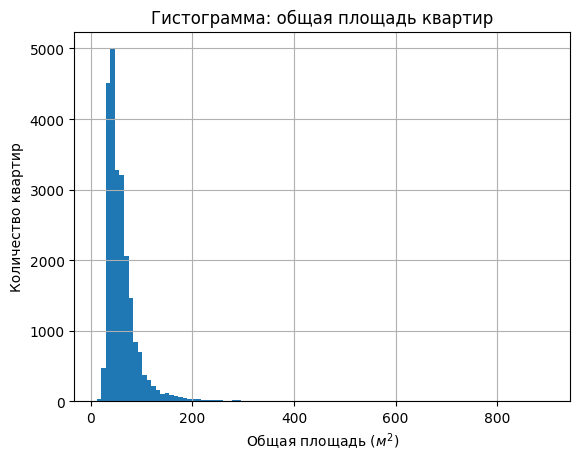

In [59]:
import matplotlib.pyplot as plt
data['total_area'].hist(bins=100)
plt.title("Гистограмма: общая площадь квартир")
plt.xlabel("Общая площадь ($м^2$)")
plt.ylabel("Количество квартир")
plt.show()

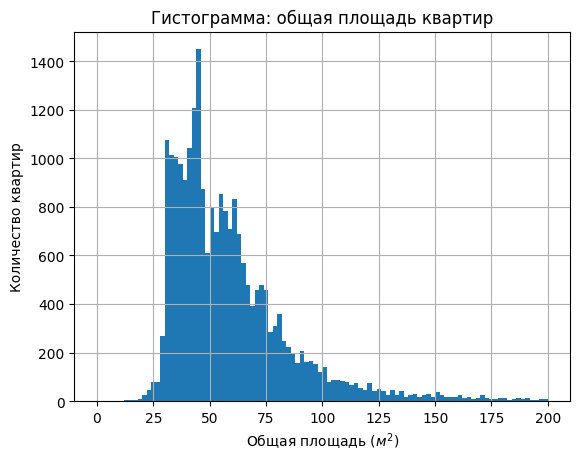

In [60]:
import matplotlib.pyplot as plt
data['total_area'].hist(bins=100, range=(0,200))
plt.title("Гистограмма: общая площадь квартир")
plt.xlabel("Общая площадь ($м^2$)")
plt.ylabel("Количество квартир")
plt.show()

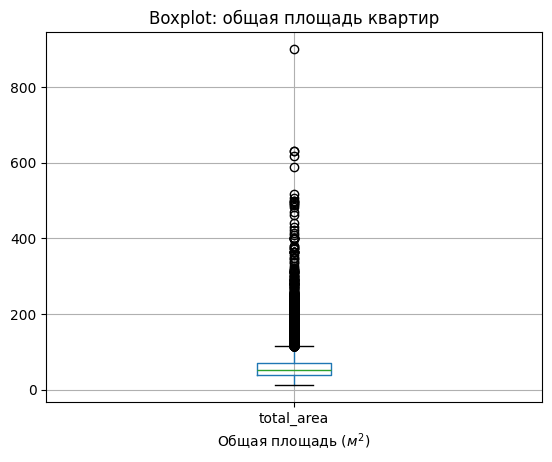

In [61]:
import matplotlib.pyplot as plt
data.boxplot(column = ['total_area'])
plt.title("Boxplot: общая площадь квартир")
plt.xlabel("Общая площадь ($м^2$)")
plt.show()

Есть квартиры с аномально большой площадью (200-900). Также есть подозрительно маленькие (около 12). Самая распространенная площадь - около 50. Стандартное отклонение 35 - досточно большое (то есть вероятны аномалии).

Избавимся от аномально больших значений

> Добавить блок с цитатой



In [62]:
anomal_area_count = len(data[data['total_area']>200])
anomal_area_count

225

In [63]:
total = len(data)
total

23346

In [64]:
100 * anomal_area_count/total

0.9637625289128758

Доля квартир с площадью больше 200 менее 1%. Удалим эти данные.

In [65]:
data = data[data['total_area']<200]
len(data)

23117

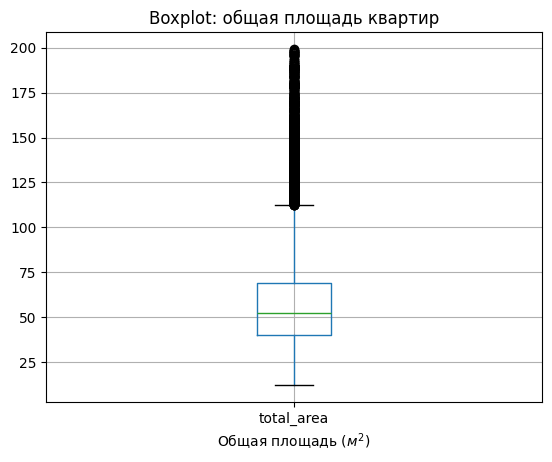

In [66]:
import matplotlib.pyplot as plt
data.boxplot(column = ['total_area'])
plt.title("Boxplot: общая площадь квартир")
plt.xlabel("Общая площадь ($м^2$)")
plt.show()

Как видно, все равно много аномальных значений на промежутке от 100 до 200.

In [67]:
anomal_area_count = len(data[data['total_area']>100])
total = len(data)
100 * anomal_area_count/total

6.8780551109573045

Таких квартир довольно много. Может быть эта категория требует дополнительного анализа.
Пока будем исследовать основную часть данных. Поэтому просто избавимся от аномалий.

In [68]:
data = data[data['total_area']<100]
len(data)

21456

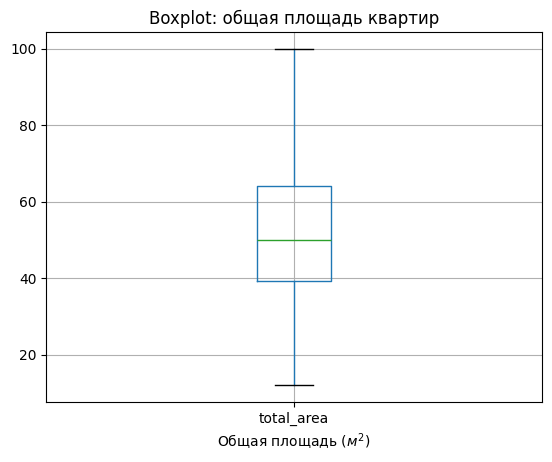

In [69]:
import matplotlib.pyplot as plt
data.boxplot(column = ['total_area'])
plt.title("Boxplot: общая площадь квартир")
plt.xlabel("Общая площадь ($м^2$)")
plt.show()

Цена

In [70]:
data['last_price'].describe()

,last_price
count,2.145600e+04
mean,5.080967e+06
std,2.941199e+06
min,4.300000e+05
25%,3.350000e+06
50%,4.462500e+06
75%,6.099000e+06
max,5.300000e+07


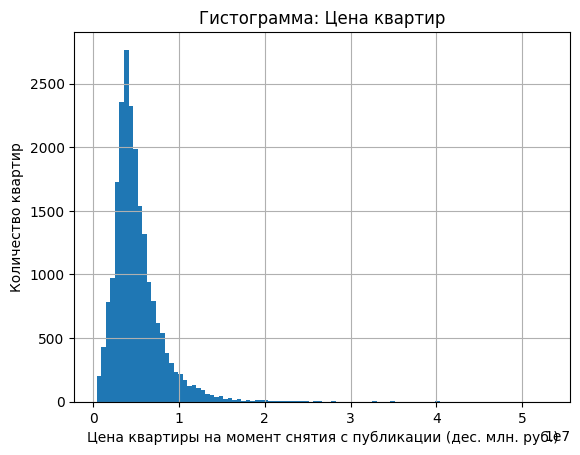

In [71]:
import matplotlib.pyplot as plt
data['last_price'].hist(bins=100)
plt.title("Гистограмма: Цена квартир")
plt.xlabel("Цена квартиры на момент снятия с публикации (дес. млн. руб.)")
plt.ylabel("Количество квартир")
plt.show()

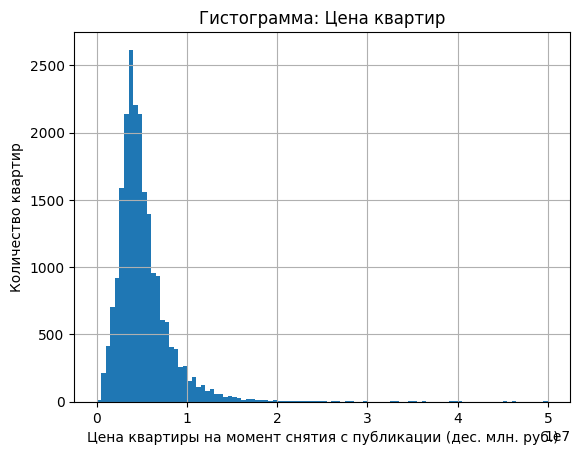

In [72]:
import matplotlib.pyplot as plt
data['last_price'].hist(bins=100, range=(0,50000000))
plt.title("Гистограмма: Цена квартир")
plt.xlabel("Цена квартиры на момент снятия с публикации (дес. млн. руб.)")
plt.ylabel("Количество квартир")
plt.show()

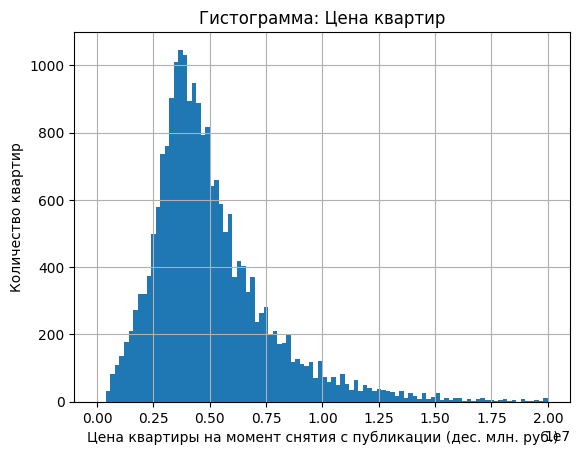

In [73]:
import matplotlib.pyplot as plt
data['last_price'].hist(bins=100, range=(0,20000000))
plt.title("Гистограмма: Цена квартир")
plt.xlabel("Цена квартиры на момент снятия с публикации (дес. млн. руб.)")
plt.ylabel("Количество квартир")
plt.show()

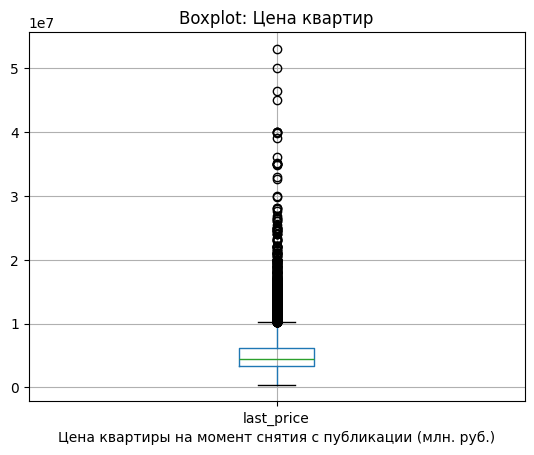

In [74]:
import matplotlib.pyplot as plt
data.boxplot(column = ['last_price'])
plt.title("Boxplot: Цена квартир")
plt.xlabel("Цена квартиры на момент снятия с публикации (млн. руб.)")
plt.show()

Минимальная и максимальная цены очень сильно отличаются. Самая распространенная цена - 4650000. Стандратное отклонение большое, что может свидетельствовать о наличии аномальных значений. Boxplot также говорит о наличии большого количества выбросов (больше 10000000).  

Избавимся от аномалий

In [75]:
anomal_price_count = len(data[data['last_price']>10000000])
total = len(data)
100 * anomal_price_count/total

5.210663683818046

Здесь тоже большой процент выбросов. Это еще раз заставляет задуматься о том, что вероятно лучше исходные данные разбить на разные категории (например, стандартные и элитные квартиры) и затем их анализ проводить отдельно. Пока будем исследовать стандартные квартиры стоимость до 9 млн.руб.. Избавимся от аномалий.

In [76]:
data = data[data['last_price']<9000000]
len(data)

19767

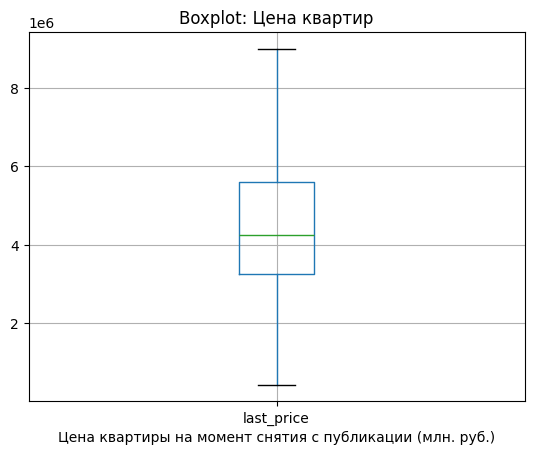

In [77]:
import matplotlib.pyplot as plt
data.boxplot(column = ['last_price'])
plt.title("Boxplot: Цена квартир")
plt.xlabel("Цена квартиры на момент снятия с публикации (млн. руб.)")
plt.show()

Число комнат

In [78]:
data['rooms'].describe()

,rooms
count,19767.000000
mean,1.870289
std,0.843922
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,6.000000


In [79]:
data['rooms'].value_counts()

,count
rooms,
1,7900
2,7088
3,4250
4,503
5,24
6,2


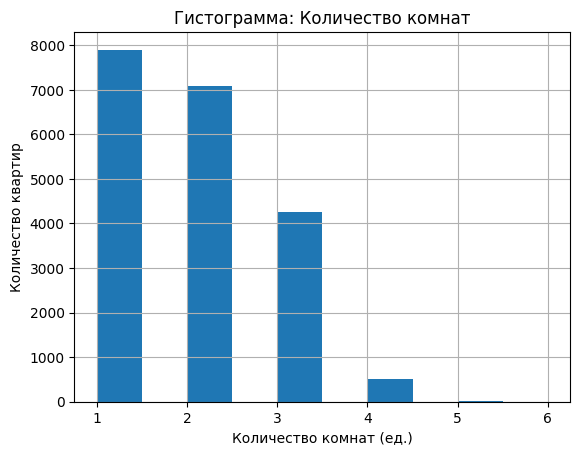

In [80]:
import matplotlib.pyplot as plt
data['rooms'].hist(bins=10)
plt.title("Гистограмма: Количество комнат")
plt.xlabel("Количество комнат (ед.)")
plt.ylabel("Количество квартир")
plt.show()

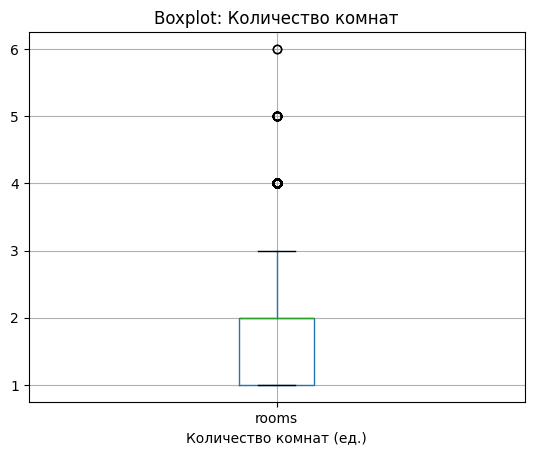

In [81]:
import matplotlib.pyplot as plt
data.boxplot(column = ['rooms'])
plt.title("Boxplot: Количество комнат")
plt.xlabel("Количество комнат (ед.)")
plt.show()

Больше всего продается квартир с количеством комнат 1-3. Минимальное значение - 1. Максимальное - 6 (очень мало).  Стандартное отклонение - меньше 1. Самые распространенные из выставленных на продажу - 1-комнатные и 2-х комнатные квартиры.

In [82]:
anomal_rooms_count = len(data[data['rooms']>=4])
total = len(data)
100 * anomal_rooms_count/total

2.6761774674963323

In [83]:
data = data[data['rooms']<4]
len(data)

19238

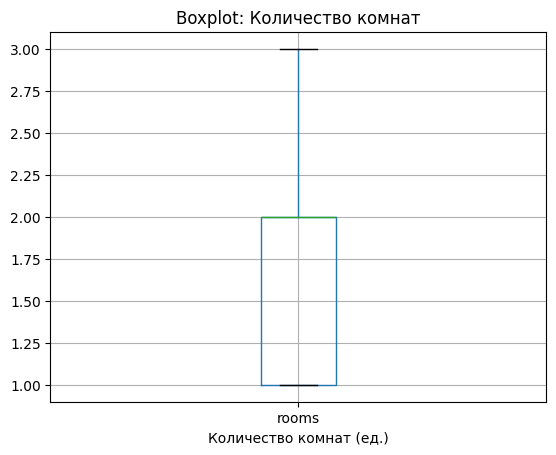

In [84]:
import matplotlib.pyplot as plt
data.boxplot(column = ['rooms'])
plt.title("Boxplot: Количество комнат")
plt.xlabel("Количество комнат (ед.)")
plt.show()

Высота потолков

In [85]:
data['ceiling_height'].describe()

,ceiling_height
count,19238.000000
mean,2.659521
std,0.180590
min,1.000000
25%,2.580000
50%,2.650000
75%,2.650000
max,8.300000


In [86]:
data['ceiling_height'].value_counts()

,count
ceiling_height,
2.65,8291
2.50,3317
2.60,1513
2.70,1355
2.55,929
...,...
3.48,1
1.00,1
3.49,1


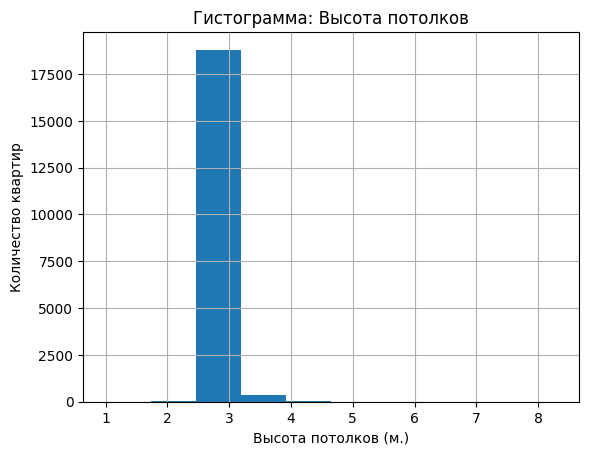

In [87]:
import matplotlib.pyplot as plt
data['ceiling_height'].hist(bins=10)
plt.title("Гистограмма: Высота потолков")
plt.xlabel("Высота потолков (м.)")
plt.ylabel("Количество квартир")
plt.show()

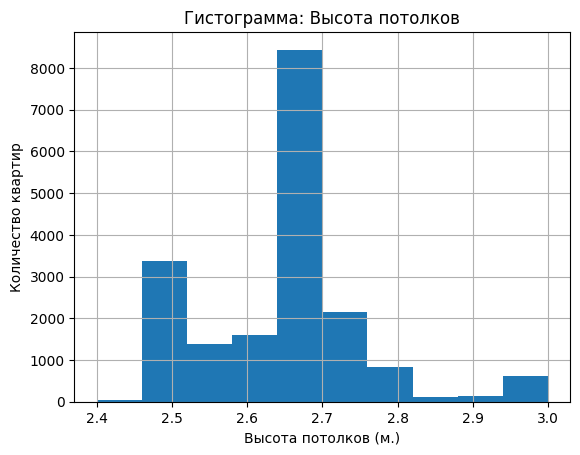

In [88]:
import matplotlib.pyplot as plt
data['ceiling_height'].hist(bins=10, range=(2.4,3.0))
plt.title("Гистограмма: Высота потолков")
plt.xlabel("Высота потолков (м.)")
plt.ylabel("Количество квартир")
plt.show()

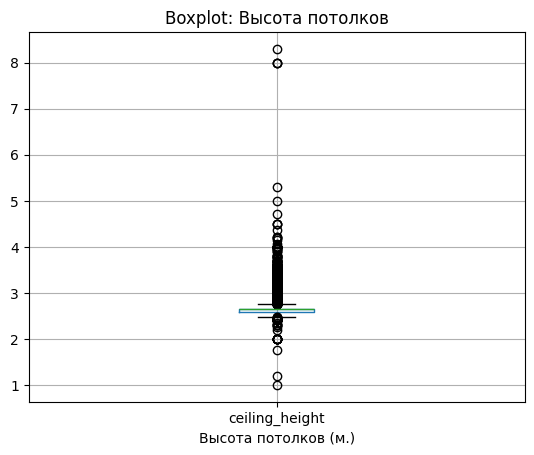

In [89]:
import matplotlib.pyplot as plt
data.boxplot(column = ['ceiling_height'])
plt.title("Boxplot: Высота потолков")
plt.xlabel("Высота потолков (м.)")
plt.show()

Минимальная высота потолков - 1 (очень странное значение. Наверное нужно проверить данные). Максимальная высота потолков - 8,3. Основная часть потолков с высотой от 2.51 до 2.81. Есть выбросы.

Избавимся от аномалий.

In [90]:
anomal_ceiling_height = len(data[data['ceiling_height']<2.4])
total = len(data)
100 * anomal_ceiling_height/total

0.10396091069757771

In [91]:
data = data[data['ceiling_height']>2.4]
len(data)

19196

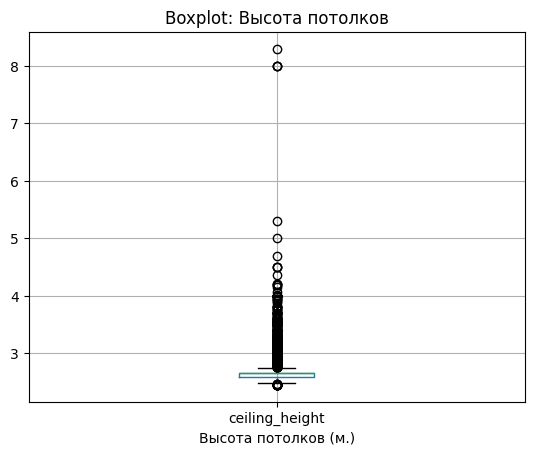

In [92]:
import matplotlib.pyplot as plt
data.boxplot(column = ['ceiling_height'])
plt.title("Boxplot: Высота потолков")
plt.xlabel("Высота потолков (м.)")
plt.show()

In [93]:
anomal_ceiling_height = len(data[data['ceiling_height']>2.8])
total = len(data)
100 * anomal_ceiling_height/total

7.501562825588664

In [94]:
data = data[data['ceiling_height']<2.8]
len(data)

17066

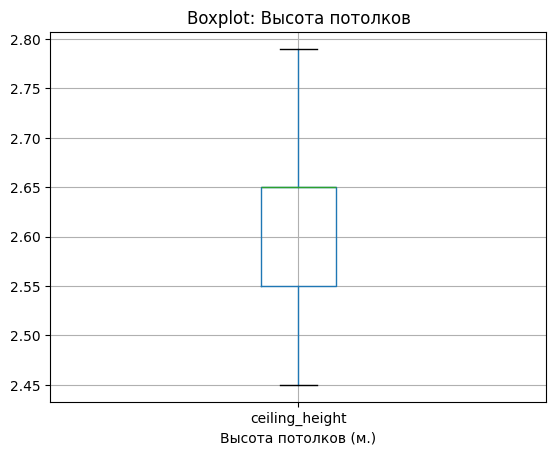

In [95]:
import matplotlib.pyplot as plt
data.boxplot(column = ['ceiling_height'])
plt.title("Boxplot: Высота потолков")
plt.xlabel("Высота потолков (м.)")
plt.show()

Время продажи квартиры

In [96]:
data['days_exposition'].describe()

,days_exposition
count,15184.000000
mean,165.146536
std,202.323624
min,1.000000
25%,42.000000
50%,88.000000
75%,208.000000
max,1580.000000


Стандартное отклонение большое. Скорее всего, в данных есть аномалии.

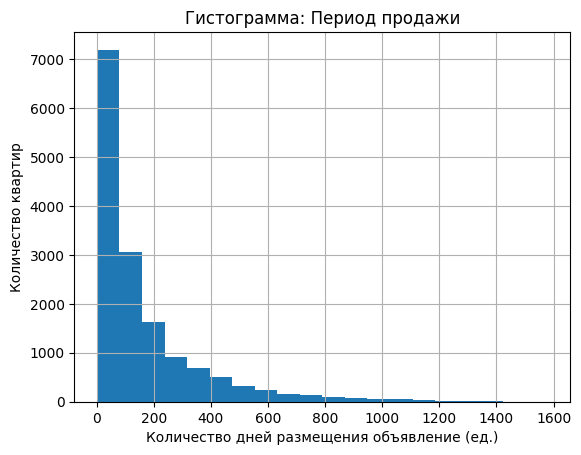

In [97]:
import matplotlib.pyplot as plt
data['days_exposition'].hist(bins=20)
plt.title("Гистограмма: Период продажи")
plt.xlabel("Количество дней размещения объявление (ед.)")
plt.ylabel("Количество квартир")
plt.show()

In [98]:
data['days_exposition'].mean() # среднее

np.float64(165.1465358271865)

In [99]:
data['days_exposition'].median() # медиана

88.00000000000001

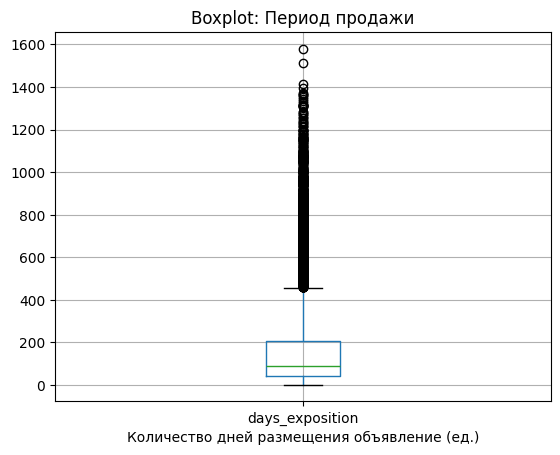

In [100]:
import matplotlib.pyplot as plt
data.boxplot(column = ['days_exposition'])
plt.title("Boxplot: Период продажи")
plt.xlabel("Количество дней размещения объявление (ед.)")
plt.show()

Чаще всего продажа квартиры происходит за 96 дней.

Большая часть квартир продается в пределах 45 - 232 дня.

Если продажа происходит меньше, чем 45 дней - это очень быстро.

Необычно долгие продажи происходят более чем за 500 дней.

Уберем выбросы

In [101]:
anomal_days_exposition = len(data[data['days_exposition']>300])
total = len(data)
100 * anomal_days_exposition/total

14.947849525372085

Достаточно большой процент. Наверное, квартиры с длинным периодом продажи требуют дополнительного изучения. Пока удалим выбросы.

In [102]:
data = data[data['days_exposition']<250]
len(data)

12039

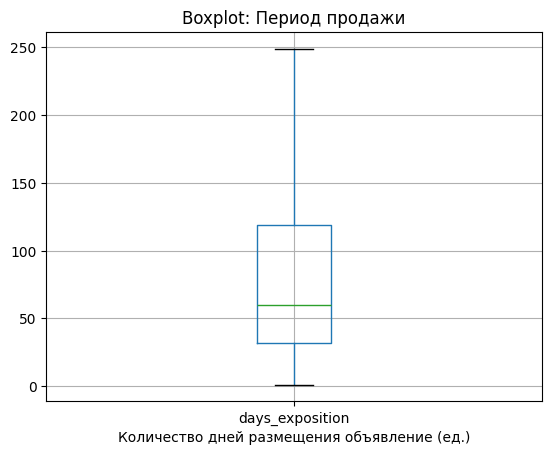

In [103]:
import matplotlib.pyplot as plt
data.boxplot(column = ['days_exposition'])
plt.title("Boxplot: Период продажи")
plt.xlabel("Количество дней размещения объявление (ед.)")
plt.show()

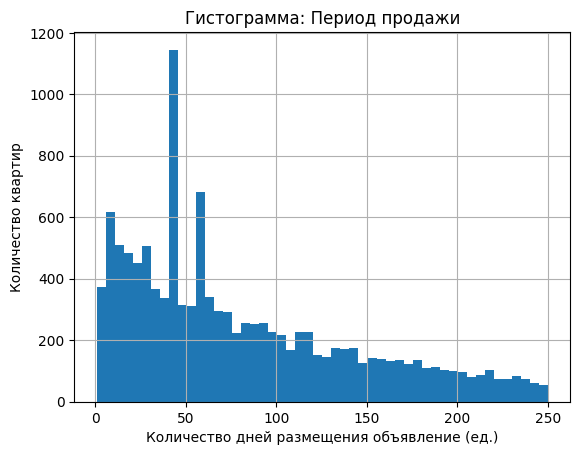

In [104]:
import matplotlib.pyplot as plt
data['days_exposition'].hist(bins=50, range=(1,250))
plt.title("Гистограмма: Период продажи")
plt.xlabel("Количество дней размещения объявление (ед.)")
plt.ylabel("Количество квартир")
plt.show()

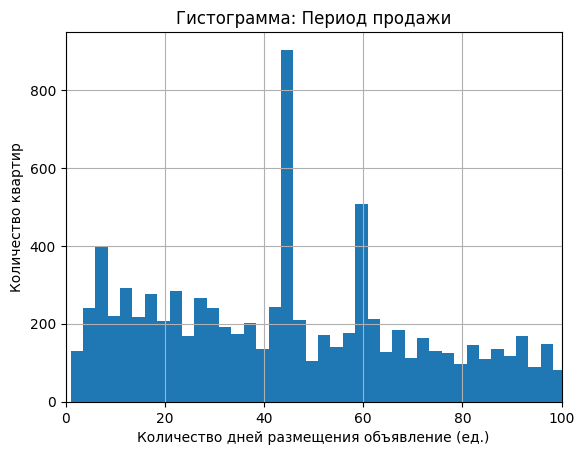

In [105]:
import matplotlib.pyplot as plt
data['days_exposition'].hist(bins=200, range=(1,500))
plt.title("Гистограмма: Период продажи")
plt.xlabel("Количество дней размещения объявление (ед.)")
plt.ylabel("Количество квартир")
plt.xlim(0, 100)
plt.show()

По гистограмме можно сделать вывод, что в основном чем больше период времени, тем меньше непроданных квартир.

Однако, при этом наблюдаются модальные пики около 40 и около 60 дней. Возможно, в основном квартиры продаются за 2 месяца. Или это может быть связано с

Проанализируем, какие факторы больше всего влияют на стоимость квартиры?

Изучим, зависит ли цена от площади

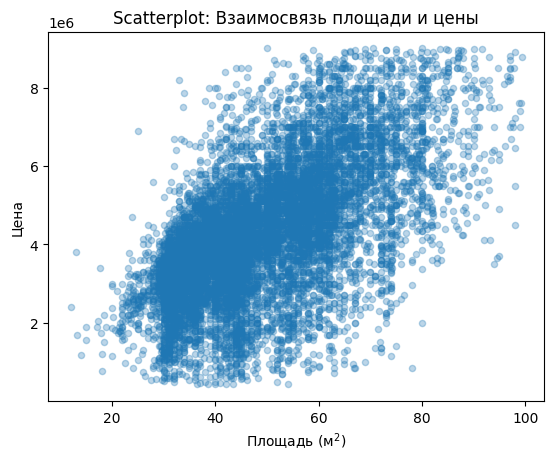

In [106]:
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
matplotlib_axes_logger.setLevel('ERROR')
data.plot(x='total_area', y='last_price', kind='scatter', alpha=0.3)
plt.title("Scatterplot: Взаимосвязь площади и цены")
plt.xlabel("Площадь (м$^2$)")
plt.ylabel("Цена")
plt.show()

Найдем коэффициент корреляции Пирсона

In [107]:
data['total_area'].corr(data['last_price'])

np.float64(0.6194193031227466)

Из диаграммы рассеяния видно, что чем больше площадь, тем выше цена. Коэффициент корреляции 0,61 говорит о наличии линейной зависимости, но не слишком сильной. Вероятно, цена не всегда связана только с площадью.

Изучим, зависит ли цена от числа комнат

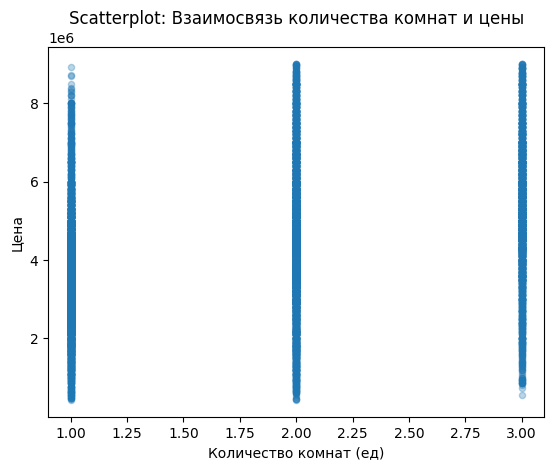

In [108]:
import matplotlib.pyplot as plt
data.plot(x='rooms', y='last_price', kind='scatter', alpha=0.3)
plt.title("Scatterplot: Взаимосвязь количества комнат и цены")
plt.xlabel("Количество комнат (ед)")
plt.ylabel("Цена")
plt.show()

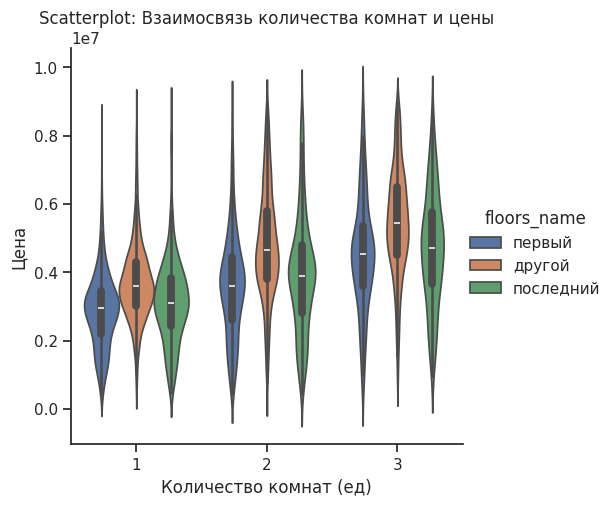

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", color_codes=True)
sns.catplot(x="rooms", y="last_price", hue="floors_name", data=data, kind='violin')
plt.title("Scatterplot: Взаимосвязь количества комнат и цены")
plt.xlabel("Количество комнат (ед)")
plt.ylabel("Цена")
plt.show()

Найдем коэффициент корреляции Пирсона

In [110]:
data['rooms'].corr(data['last_price'])

np.float64(0.4010624559840185)

Линейной зависимости нет. В основном дороже стоят квартиры с числом комнат от 2 и 3. Скорее всего, это самые востребованные на рынке квартиры. Кроме того, большое число комнат еше не говорит о большой площади. Коэффициент корреляции также говорит об отсутствии линейной зависимости.

Изучим, зависит ли цена от этажа (первого или последнего).

На предыдущем графике видно, что квартиры на первом и последнем этажах стоят дешевле.

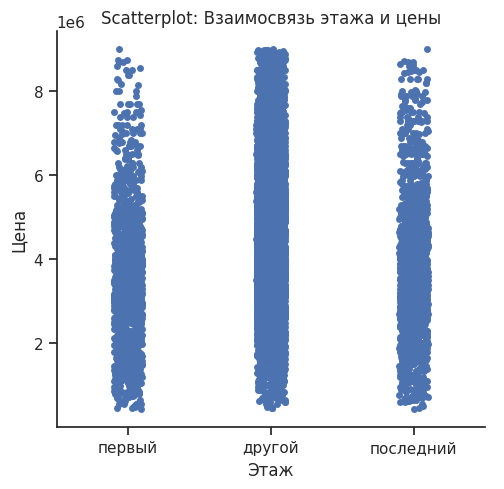

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", color_codes=True)
sns.catplot(x="floors_name", y="last_price", data=data)
plt.title("Scatterplot: Взаимосвязь этажа и цены")
plt.xlabel("Этаж")
plt.ylabel("Цена")
plt.show()

Цена зависит от этажа. Квартиры на первом и последнем этажах в основном дешевле.

Изучим, зависит ли цена от удалённости от центра.

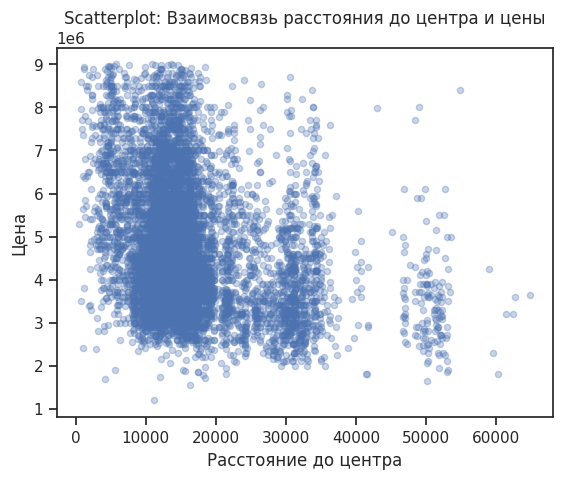

In [112]:
import matplotlib.pyplot as plt
data.plot(x='cityCenters_nearest', y='last_price', kind='scatter', alpha=0.3)
plt.title("Scatterplot: Взаимосвязь расстояния до центра и цены")
plt.xlabel("Расстояние до центра")
plt.ylabel("Цена")
plt.show()

Из диаграммы видно, что квартиры, которые находится в удалении от центра в пределах 10 км, стоят дороже. Чем дальше квартиры от центра, тем ниже ее стоимость.

Найдем коэффициент корреляции Пирсона

In [113]:
data['cityCenters_nearest'].corr(data['last_price'])

np.float64(-0.2865670265960624)

Коэффициент корреляции близок к нулю, что говорит об отсутствии линейной зависимости. Отрицательное значение говорит об обратной связи (чем ближе квартира к центру, тем больше ее цена).

Изучим, зависит ли цена от даты размещения: дня недели, месяца и года.

День недели

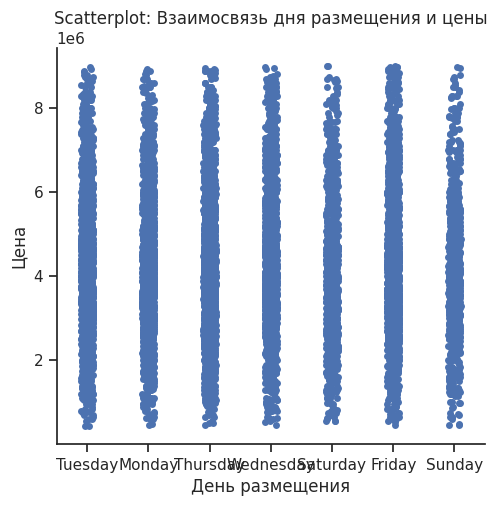

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", color_codes=True)
sns.catplot(x="exposition_weekday", y="last_price", data=data)
plt.title("Scatterplot: Взаимосвязь дня размещения и цены")
plt.xlabel("День размещения")
plt.ylabel("Цена")
plt.show()

Месяц

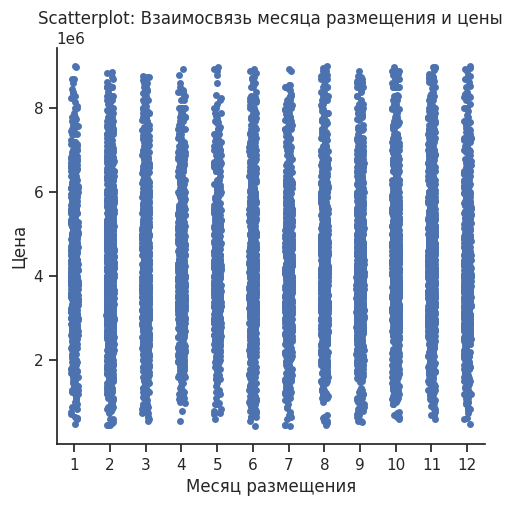

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", color_codes=True)
sns.catplot(x="exposition_month", y="last_price", data=data)
plt.title("Scatterplot: Взаимосвязь месяца размещения и цены")
plt.xlabel("Месяц размещения")
plt.ylabel("Цена")
plt.show()

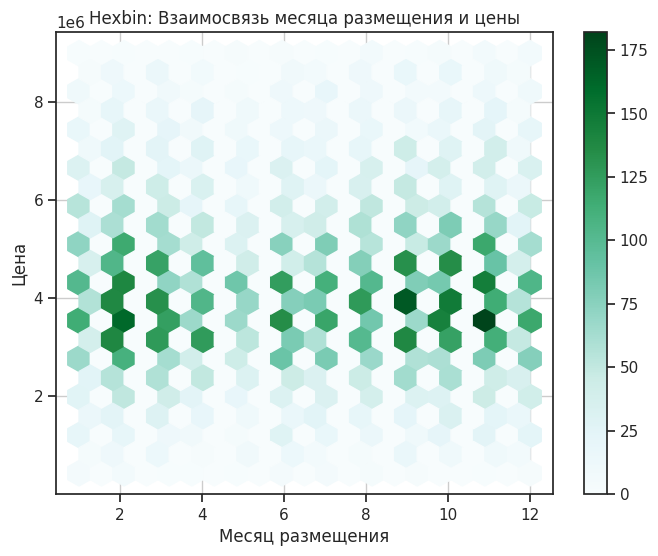

In [116]:
import matplotlib.pyplot as plt
data.plot(x='exposition_month', y='last_price', kind='hexbin', gridsize=20, figsize=(8, 6), sharex=False, grid=True)
plt.title("Hexbin: Взаимосвязь месяца размещения и цены")
plt.xlabel("Месяц размещения")
plt.ylabel("Цена")
plt.show()

Год

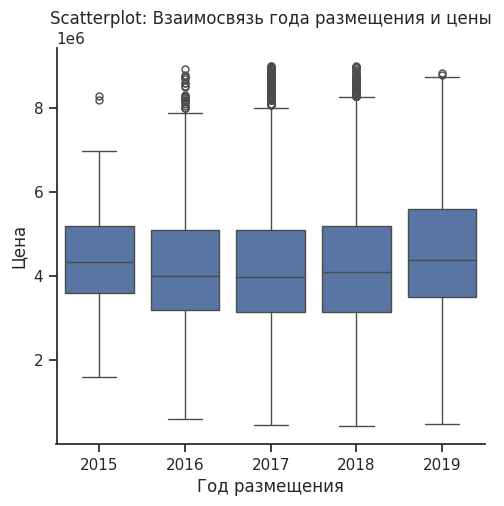

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", color_codes=True)
sns.catplot(x="exposition_year", y="last_price", data=data, kind='box')
plt.title("Scatterplot: Взаимосвязь года размещения и цены")
plt.xlabel("Год размещения")
plt.ylabel("Цена")
plt.show()

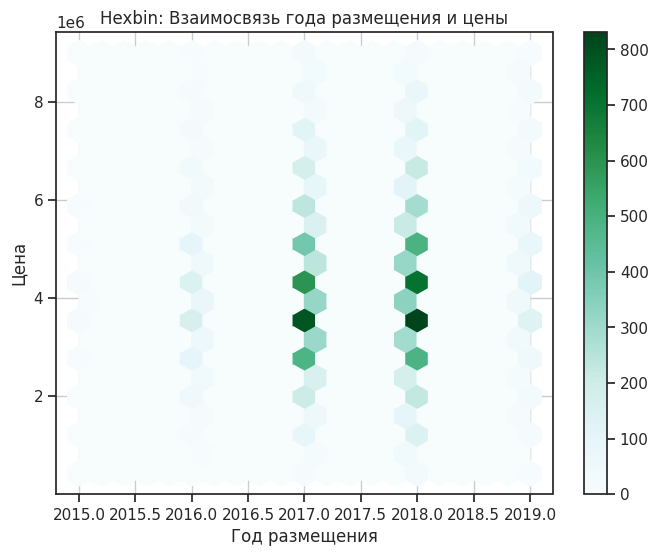

In [118]:
import matplotlib.pyplot as plt
data.plot(x='exposition_year', y='last_price', kind='hexbin', gridsize=20, figsize=(8, 6), sharex=False, grid=True)
plt.title("Hexbin: Взаимосвязь года размещения и цены")
plt.xlabel("Год размещения")
plt.ylabel("Цена")
plt.show()

Цена мало зависит от дня недели.

Квартиры стоят дороже в в период с февраля по апрель и в ноябре.

В период с 2014 по 2018 годы цена росла. При этом, в 2014 году цена заметно ниже. В 2019 г. заметно снижение цены по сравнению с 2018 г. Дороже всего квартиры были в 2017 и 2018 годах.

In [119]:
data.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'cityCenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition', 'metr_price', 'exposition_weekday',
       'exposition_month', 'exposition_year', 'floors_name',
       'ratio_living_total', 'ratio_kitchen__total'],
      dtype='object')

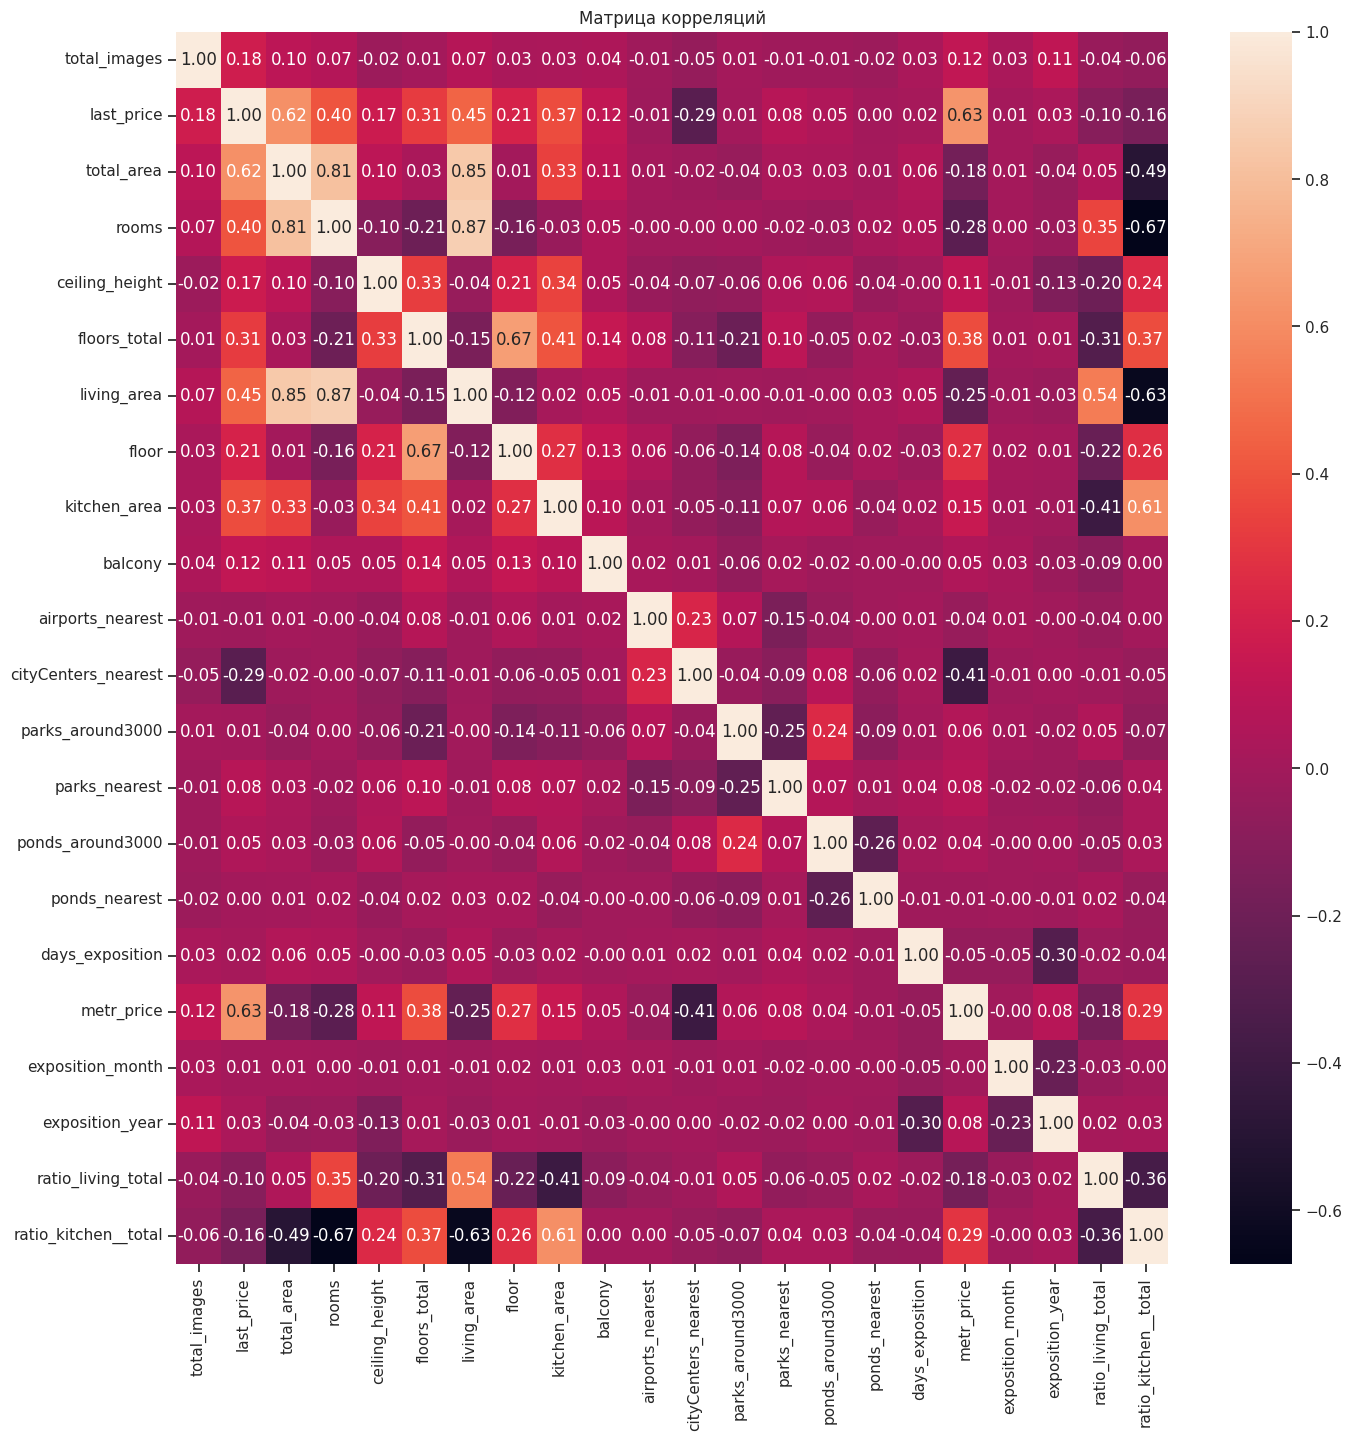

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(16,16))
sns.heatmap(data.select_dtypes('number').corr(), annot=True, fmt='.2f')
plt.title("Матрица корреляций")
plt.show()

Из тепловой карты видно, что есть связь между ценой квадратного метра и ценой квартиры, между общей площадью и ценой, вероятна связь между жилой площадью и ценой.

Выберем 10 населённых пунктов с наибольшим числом объявлений.

In [121]:
data_locality = data.groupby('locality_name').count()
data_locality.sort_values(by=['first_day_exposition'], ascending=False)['first_day_exposition'].head(10)

,first_day_exposition
locality_name,
Санкт-Петербург,7367
посёлок Мурино,394
посёлок Шушары,309
посёлок Парголово,234
Колпино,225
Всеволожск,214
деревня Кудрово,195
Гатчина,184
Пушкин,178


In [122]:
data_locality_top10 = data.query('locality_name in ["Санкт-Петербург", "посёлок Мурино", "посёлок Шушары", "Всеволожск", "Пушкин", "Колпино", "посёлок Парголово", "Гатчина", "деревня Кудрово", "Выборг"]')

Средняя стоимость квадратного метра жилья

In [123]:
data_locality_top10.pivot_table(index='locality_name', values='metr_price').sort_values(by='metr_price', ascending=False)

,metr_price
locality_name,
Санкт-Петербург,102171.024569
Пушкин,97853.831461
деревня Кудрово,92089.430769
посёлок Парголово,89361.623932
посёлок Мурино,85631.926396
посёлок Шушары,77956.245955
Колпино,75344.093333
Гатчина,68287.978261
Всеволожск,66751.042056


Самая большая стоимость квадратного метра в Санкт-Петербурге, самая низкая - в Выборге.

Выделим квартиры в Санкт-Петербурге.

In [124]:
data_sp = data.query('locality_name == "Санкт-Петербург"').copy()

Создадим столбец с расстоянием до центра в километрах:

In [125]:
data_sp['cityCenters_km'] = round(data_sp['cityCenters_nearest'] / 1000)
data_sp.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_nearest,days_exposition,metr_price,exposition_weekday,exposition_month,exposition_year,floors_name,ratio_living_total,ratio_kitchen__total,cityCenters_km
10,5,5050000.0,39.6,2017-11-16,1,2.67,12,20.3,3,False,...,553.0,137.0,127525.0,Thursday,11,2017,другой,0.512626,0.214646,14.0
15,16,4650000.0,39.0,2017-11-18,1,2.65,14,20.5,5,False,...,296.0,19.0,119231.0,Saturday,11,2017,другой,0.525641,0.194872,14.0
18,8,3250000.0,31.0,2017-01-27,1,2.50,5,19.4,2,False,...,NaN,168.0,104839.0,Friday,1,2017,другой,0.625806,0.180645,11.0
27,20,7100000.0,70.0,2017-05-12,3,2.60,17,49.0,11,False,...,779.0,151.0,101429.0,Friday,5,2017,другой,0.700000,0.131429,11.0
32,7,4990000.0,60.0,2016-05-22,3,2.65,5,39.0,4,False,...,426.0,224.0,83167.0,Sunday,5,2016,другой,0.650000,0.100000,13.0
34,3,3290000.0,33.0,2018-02-04,1,2.55,16,14.0,3,False,...,NaN,15.0,99697.0,Sunday,2,2018,другой,0.424242,0.242424,13.0
36,13,3790000.0,45.0,2017-01-25,2,2.65,9,27.0,9,False,...,NaN,139.0,84222.0,Wednesday,1,2017,последний,0.600000,0.140000,16.0
39,15,5200000.0,54.4,2018-11-29,2,2.75,9,29.7,2,False,...,1175.0,29.0,95588.0,Thursday,11,2018,другой,0.545956,0.161765,12.0
41,16,7900000.0,74.0,2016-05-04,3,2.65,14,59.0,8,False,...,759.0,179.0,106757.0,Wednesday,5,2016,другой,0.797297,0.162162,13.0
54,6,3320000.0,36.5,2017-04-14,1,2.65,24,14.0,6,False,...,NaN,44.0,90959.0,Friday,4,2017,другой,0.383562,0.328767,14.0


Найдем среднюю цену для каждого километра.

In [126]:
data_sp_km = data_sp.pivot_table(index='cityCenters_km', values='last_price').sort_values(by='last_price', ascending=False)
data_sp_km

,last_price
cityCenters_km,
2.0,6.646774e+06
5.0,6.541494e+06
1.0,6.527588e+06
28.0,6.300000e+06
4.0,6.046432e+06
3.0,5.871587e+06
6.0,5.713046e+06
7.0,5.690631e+06
0.0,5.300000e+06


Построим график, показывающий зависимость цены от удалённости от центра.

In [127]:
data_sp_km = data_sp_km.sort_values(by='cityCenters_km')

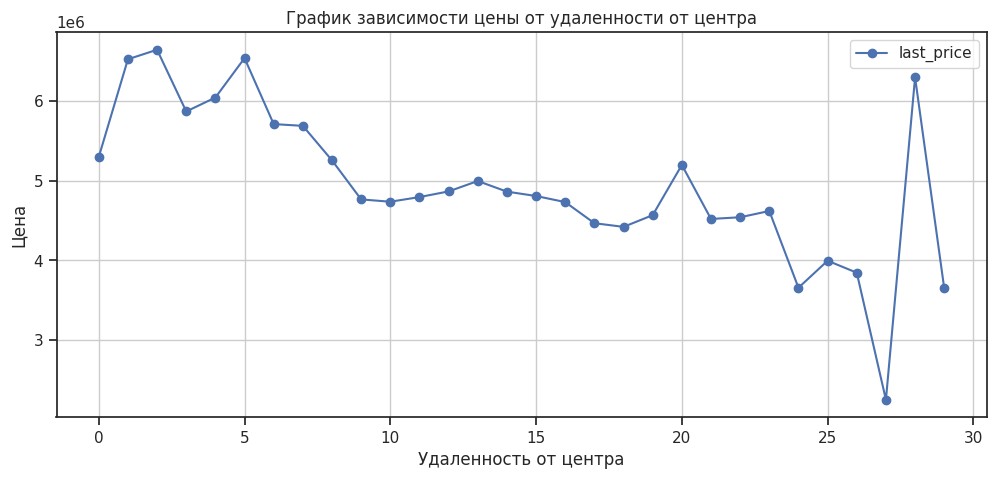

In [128]:
import matplotlib.pyplot as plt
data_sp_km.plot(grid=True, figsize=(12, 5), style='o-')
plt.title("График зависимости цены от удаленности от центра")
plt.xlabel("Удаленность от центра")
plt.ylabel("Цена")
plt.show()

Цена резко начинает меняться после 8 км. Вероятно, центральная часть города ограничена радиусовм 8 км.

Выделим сегмент квартир в центре.

In [129]:
data_sp_center = data_sp.query('cityCenters_km <= 8')

In [130]:
data_sp_center[['last_price', 'total_area', 'rooms', 'ceiling_height']].describe()

,last_price,total_area,rooms,ceiling_height
count,7.980000e+02,798.000000,798.000000,798.000000
mean,5.843752e+06,52.203158,1.878446,2.634198
std,1.605813e+06,15.743392,0.738958,0.063691
min,1.686000e+06,12.000000,1.000000,2.490000
25%,4.600000e+06,41.450000,1.000000,2.650000
50%,5.800000e+06,50.000000,2.000000,2.650000
75%,7.000000e+06,62.000000,2.000000,2.650000
max,8.999000e+06,99.300000,3.000000,2.790000


In [131]:
data_sp_center1 = data_sp_center[['last_price', 'total_area', 'rooms', 'floor', 'cityCenters_km', 'exposition_year']]

array([[<Axes: xlabel='last_price', ylabel='last_price'>,
        <Axes: xlabel='total_area', ylabel='last_price'>,
        <Axes: xlabel='rooms', ylabel='last_price'>,
        <Axes: xlabel='floor', ylabel='last_price'>,
        <Axes: xlabel='cityCenters_km', ylabel='last_price'>,
        <Axes: xlabel='exposition_year', ylabel='last_price'>],
       [<Axes: xlabel='last_price', ylabel='total_area'>,
        <Axes: xlabel='total_area', ylabel='total_area'>,
        <Axes: xlabel='rooms', ylabel='total_area'>,
        <Axes: xlabel='floor', ylabel='total_area'>,
        <Axes: xlabel='cityCenters_km', ylabel='total_area'>,
        <Axes: xlabel='exposition_year', ylabel='total_area'>],
       [<Axes: xlabel='last_price', ylabel='rooms'>,
        <Axes: xlabel='total_area', ylabel='rooms'>,
        <Axes: xlabel='rooms', ylabel='rooms'>,
        <Axes: xlabel='floor', ylabel='rooms'>,
        <Axes: xlabel='cityCenters_km', ylabel='rooms'>,
        <Axes: xlabel='exposition_year', ylab

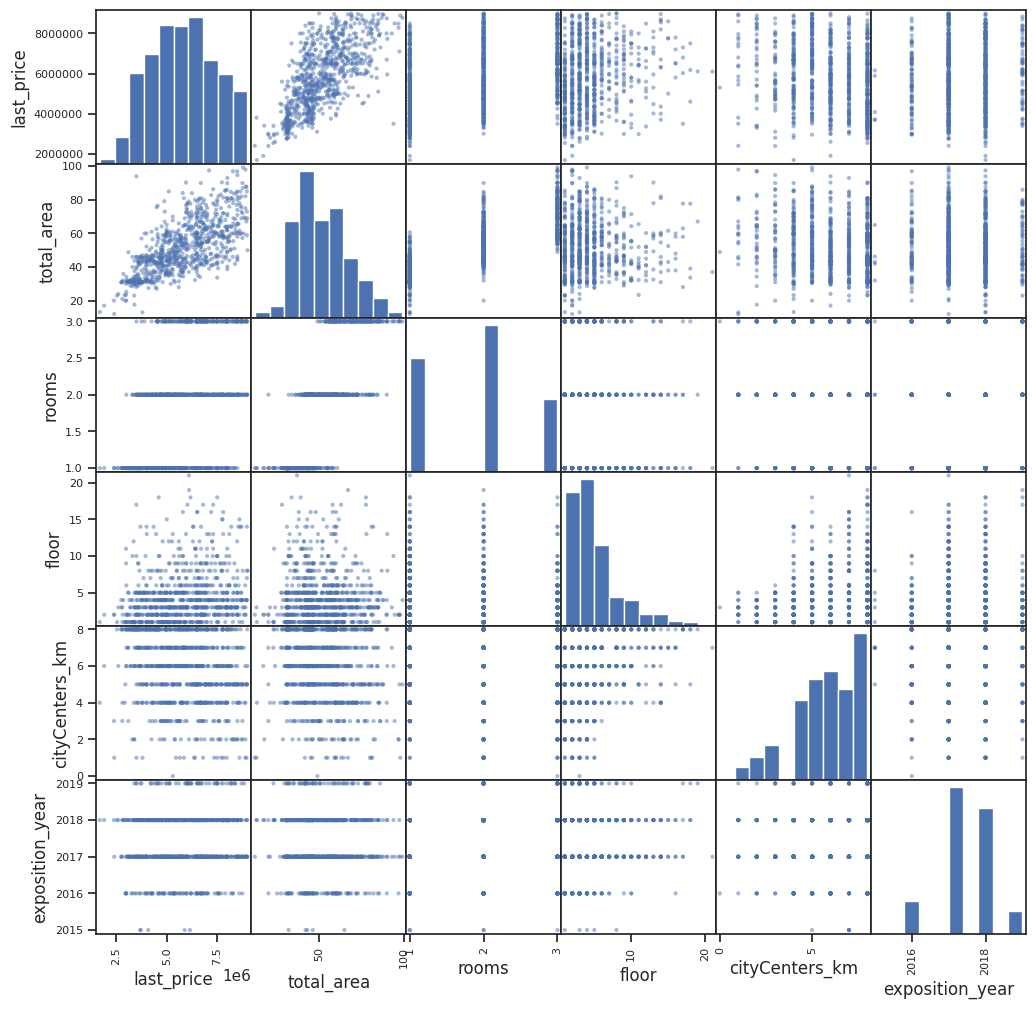

In [132]:
pd.plotting.scatter_matrix(data_sp_center1, figsize=(12, 12))

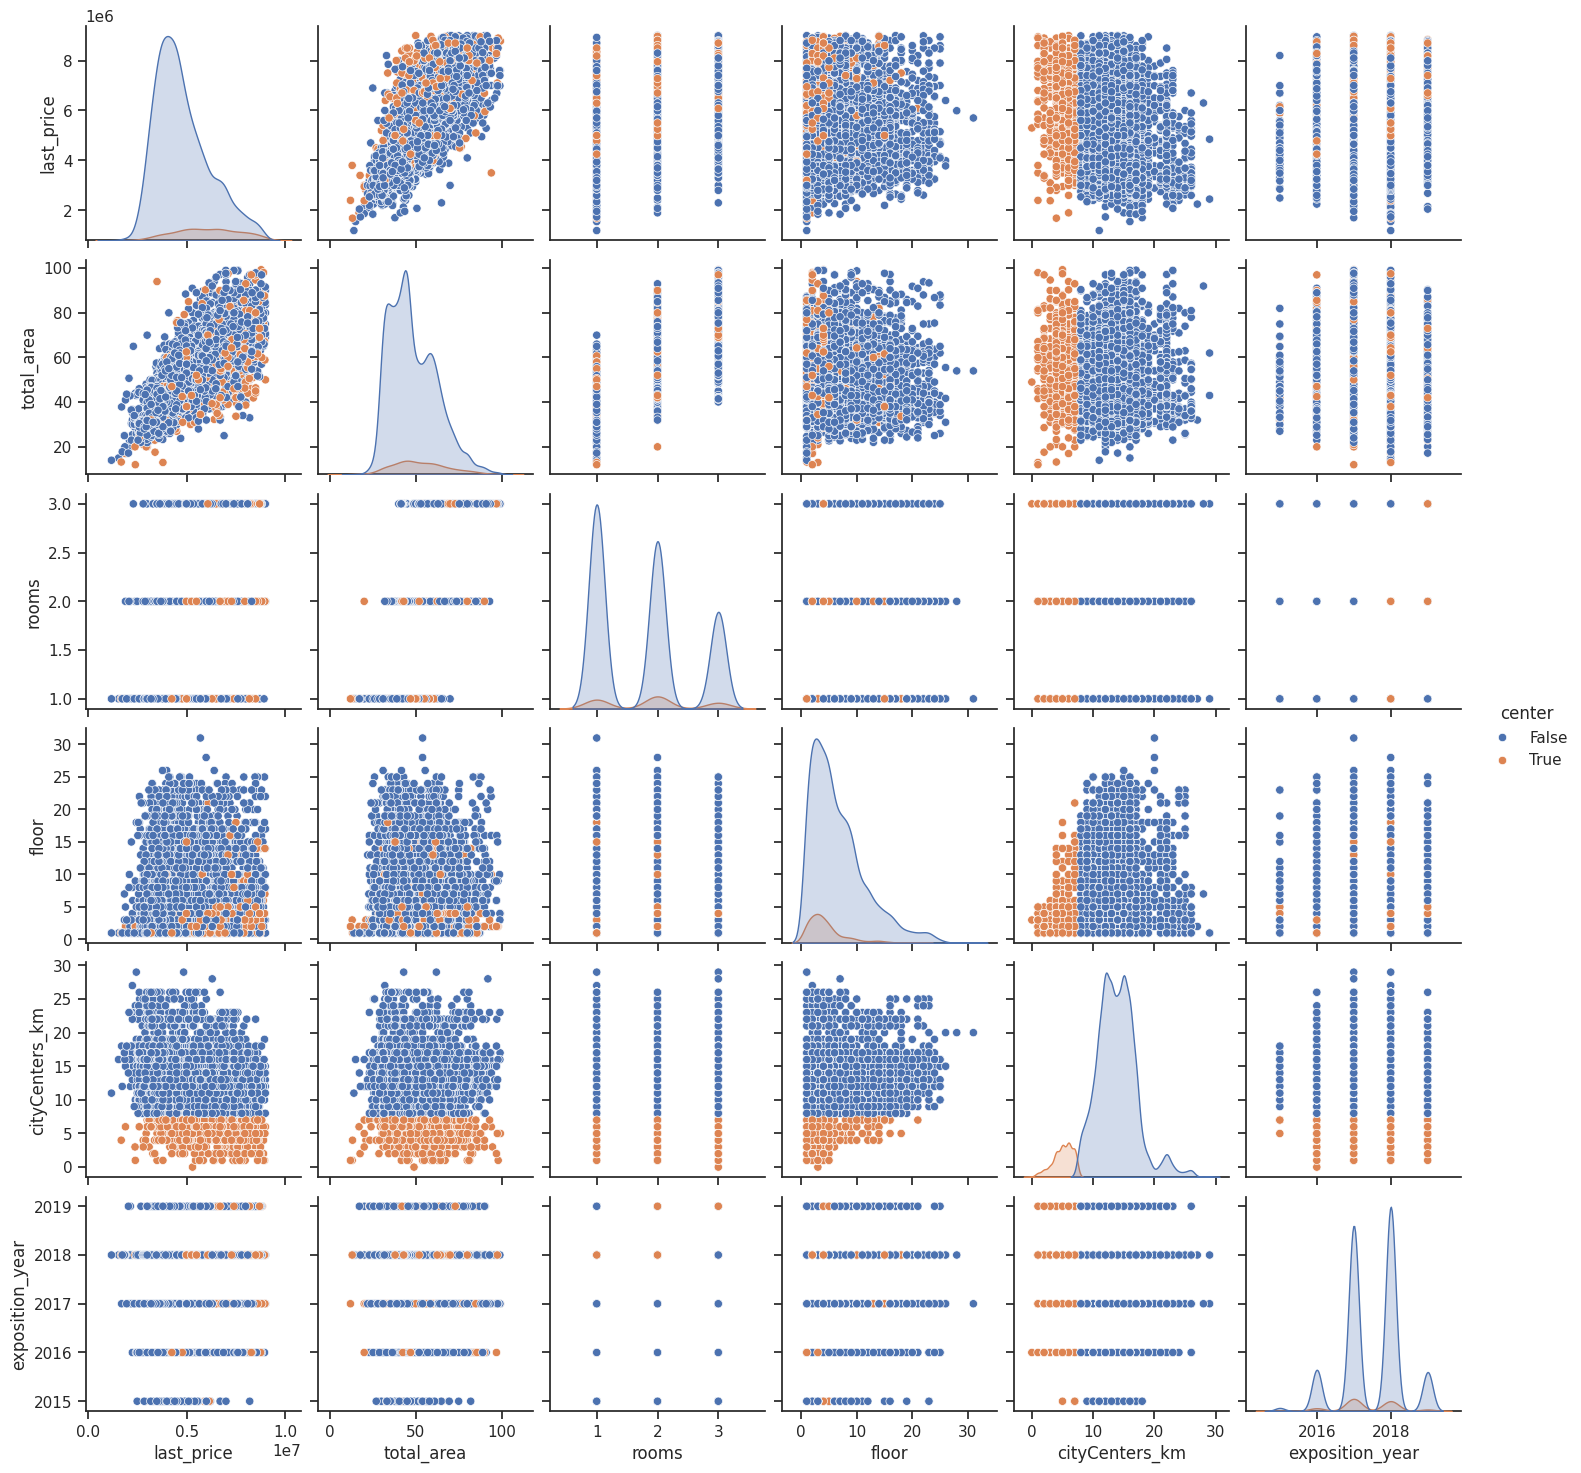

In [133]:
data_sp['center'] = data_sp['cityCenters_km'] < 8
data_sp_center1 = data_sp[['last_price', 'total_area', 'rooms', 'floor',
                                  'cityCenters_km', 'exposition_year', 'center']]
import seaborn
sns.pairplot(data_sp_center1, hue='center');

In [134]:
data_sp_center1.corr()

,last_price,total_area,rooms,floor,cityCenters_km,exposition_year,center
last_price,1.000000,0.766468,0.496695,0.143452,-0.220554,0.067064,0.237257
total_area,0.766468,1.000000,0.805734,0.018380,-0.026834,-0.032764,0.092921
rooms,0.496695,0.805734,1.000000,-0.162321,-0.038903,-0.021463,0.040417
floor,0.143452,0.018380,-0.162321,1.000000,0.140592,0.004359,-0.130855
cityCenters_km,-0.220554,-0.026834,-0.038903,0.140592,1.000000,0.032777,-0.619009
exposition_year,0.067064,-0.032764,-0.021463,0.004359,0.032777,1.000000,-0.045844
center,0.237257,0.092921,0.040417,-0.130855,-0.619009,-0.045844,1.000000


Из диаграмм и таблицы со значениями коэффициента корреляции видно, что есть сильная линейная связь между площадью и ценой. Для центральной части, расстояние от центра не так сильно влияет на цену. Наибольшая цена у квартир с количеством комнат 3-5. На этажах выше 10 цена меньше, но там как правило и площадь меньше. Дата размещения объявления вляет на цену, но зависимость не является линейной (с 2014 по 2017 цена росла, затем снижалачь).

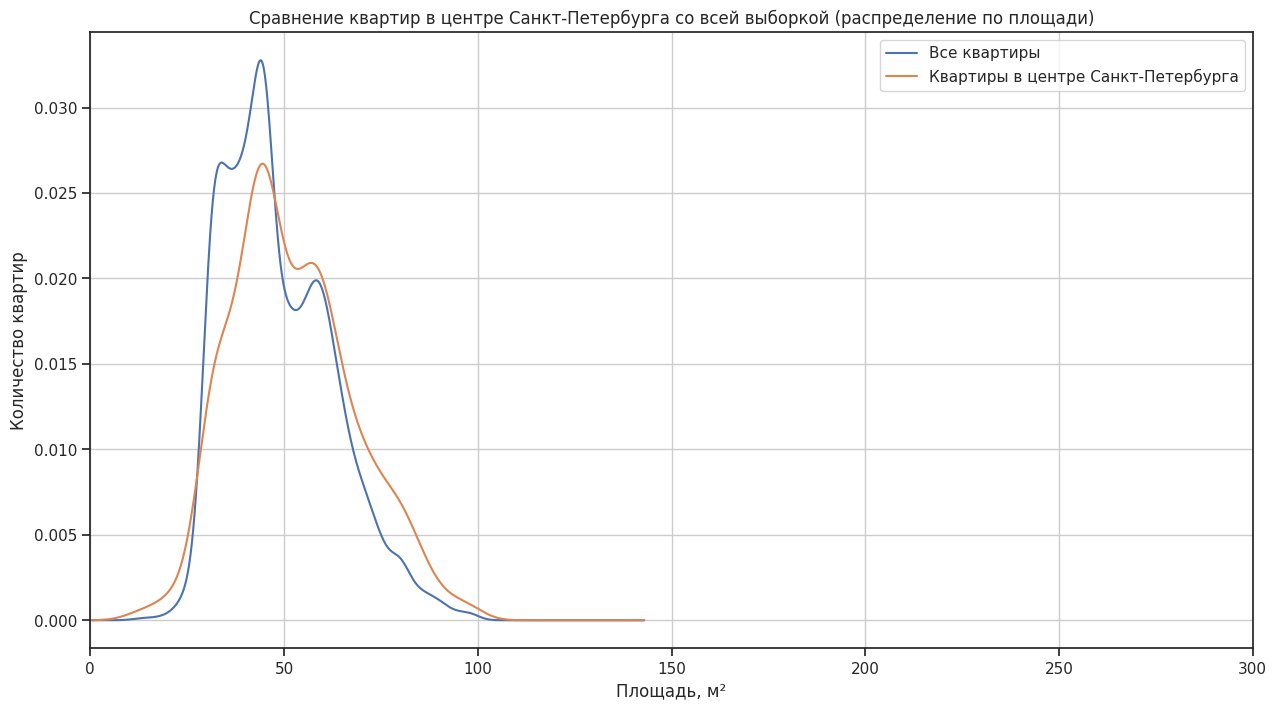

In [135]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 8))
data_sp['total_area'].plot(kind='kde',  label='Все квартиры', legend=True)
data_sp_center['total_area'].plot(kind='kde', label='Квартиры в центре Санкт-Петербурга', grid=True, legend=True)
plt.title('Сравнение квартир в центре Санкт-Петербурга со всей выборкой (распределение по площади)')
plt.xlabel('Площадь, м²')
plt.ylabel('Количество квартир')
plt.xlim([0, 300])
plt.show()

(-10000000.0, 100000000.0)

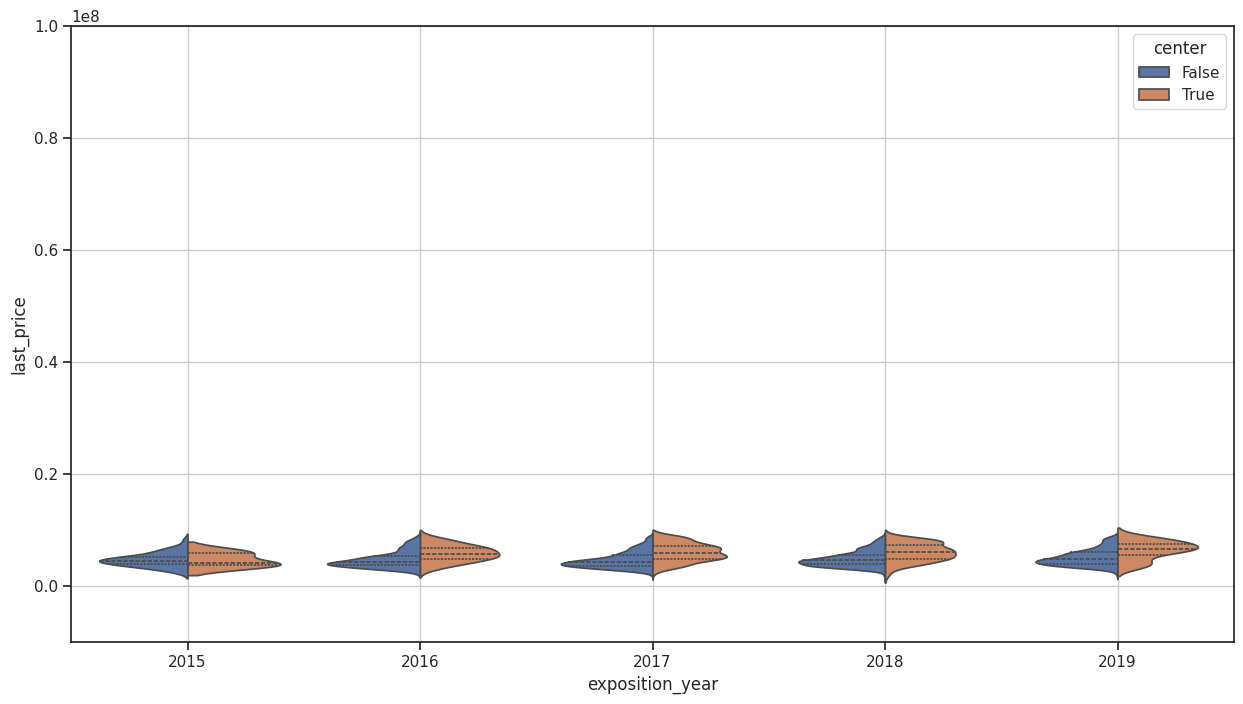

In [136]:
data_sp['center'] = data_sp['cityCenters_km'] < 8
import seaborn as sns
plt.figure(figsize=(15, 8))
sns.violinplot(x='exposition_year', y='last_price', hue='center', split=True, inner="quartile", data=data_sp)
plt.grid()
plt.ylim([-1e7, 1e8])

## Общий вывод

В общей выборке достаточно много сильно отличающихся и неправдоподобных значений (аномалий). Этот факт требует дополнительного изучения. Самая распространенная площадь выставленных на продажу квартир - около 50. Минимальная и максимальная цены очень сильно отличаются. Самая распространенная цена - 4650000. Больше всего продается квартир с количеством комнат 2 и высотой потолков от 2.51 до 2.81. Чаще всего продажа квартиры происходит за 96 дней. Самая большая стоимость квадратного метра в Санкт-Петербурге, самая низкая - в Выборге.
Квартиры стоят дороже в в период с февраля по апрель и в ноябре. В период с 2014 по 2018 годы цена росла. При этом, в 2014 году цена заметно ниже. В 2017 и 2018 годах самые высокие цены. В 2019 г. заметно снижение цены по сравнению с 2018 г.

Для Санкт-Петербурга можно провести дополнительный анализ. Цена резко начинает меняться после 8 км от центра, что позволяет выделить центральную часть города. В этой части самая распространенная цена - 7000000 , площадь - 76, количество комнат - 2, высота потолков - 2.55-2.8. Наблюдается наличие сильной линейной связи между площадью и ценой. Для центральной части, расстояние от центра не так сильно влияет на цену. Наибольшая цена у квартир с количеством комнат 3-5. На этажах выше 10 цена меньше, но там как правило и площадь меньше.

## Чек-лист готовности проекта

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  открыт файл
- [x]  файлы изучены (выведены первые строки, метод `info()`)
- [x]  определены пропущенные значения
- [x]  заполнены пропущенные значения
- [x]  есть пояснение, какие пропущенные значения обнаружены
- [x]  изменены типы данных
- [x]  есть пояснение, в каких столбцах изменены типы и почему
- [x]  посчитано и добавлено в таблицу: цена квадратного метра
- [x]  посчитано и добавлено в таблицу: день недели, месяц и год публикации объявления
- [x]  посчитано и добавлено в таблицу: этаж квартиры; варианты — первый, последний, другой
- [x]  посчитано и добавлено в таблицу: соотношение жилой и общей площади, а также отношение площади кухни к общей
- [x]  изучены следующие параметры: площадь, цена, число комнат, высота потолков
- [x]  построены гистограммы для каждого параметра
- [x]  выполнено задание: «Изучите время продажи квартиры. Постройте гистограмму. Посчитайте среднее и медиану. Опишите, сколько обычно занимает продажа. Когда можно считать, что продажи прошли очень быстро, а когда необычно долго?»
- [x]  выполнено задание: «Уберите редкие и выбивающиеся значения. Опишите, какие особенности обнаружили».
- [x]  выполнено задание: «Какие факторы больше всего влияют на стоимость квартиры? Изучите, зависит ли цена от квадратного метра, числа комнат, этажа (первого или последнего), удалённости от центра. Также изучите зависимость от даты размещения: дня недели, месяца и года».
- [x]  выполнено задание: «Выберите 10 населённых пунктов с наибольшим числом объявлений. Посчитайте среднюю цену квадратного метра в этих населённых пунктах. Выделите населённые пункты с самой высокой и низкой стоимостью жилья. Эти данные можно найти по имени в столбце `locality_name`».
- [x]  выполнено задание: «Изучите предложения квартир: для каждой квартиры есть информация о расстоянии до центра. Выделите квартиры в Санкт-Петербурге (`locality_name`). Ваша задача — выяснить, какая область входит в центр. Создайте столбец с расстоянием до центра в километрах: округлите до целых значений. После этого посчитайте среднюю цену для каждого километра. Постройте график: он должен показывать, как цена зависит от удалённости от центра. Определите границу, где график сильно меняется — это и будет центральная зона».
- [x]  выполнено задание: «Выделите сегмент квартир в центре. Проанализируйте эту территорию и изучите следующие параметры: площадь, цена, число комнат, высота потолков. Также выделите факторы, которые влияют на стоимость квартиры (число комнат, этаж, удалённость от центра, дата размещения объявления). Сделайте выводы. Отличаются ли они от общих выводов по всей базе?»
- [x]  в каждом этапе есть выводы
- [x]  есть общий вывод